# Complete NYRA Horse Racing Analysis
## From Exploratory Analysis to Predictive Modeling

**Dataset:** NYRA 2019 Complete Racing Data with GPS Features  
**Objective:** Predict horse racing finish positions using time-series machine learning

---

### Notebook Structure

**PART 1: EXPLORATORY DATA ANALYSIS**
- Load and explore the dataset
- Quality assessment and cleaning
- Univariate, bivariate, and geospatial analysis
- Feature engineering and insights
- Improved track condition visualizations 

**PART 2: MACHINE LEARNING PIPELINE**
- Time-series data splitting (NO shuffling)
- Feature preprocessing for ML
- Baseline model establishment
- Train 6 ML models with hyperparameter tuning
- Model evaluation and comparison
- Feature importance analysis (3+ methods)
- Final results and summary

---


# PART 1: EXPLORATORY DATA ANALYSIS

This section provides a comprehensive exploration of the NYRA 2019 horse racing dataset to understand:
- Dataset structure and feature distributions
- Data quality and missing values
- Relationships between features and race outcomes
- Track condition effects on performance
- GPS-derived metrics and their predictive power

**Note:** This EDA section does NOT perform any train/test splitting - that is handled in Part 2 using strict time-series methodology.

## Introduction and Problem Statement

### Problem to Solve
The New York Racing Association (NYRA) provides comprehensive tracking data that could revolutionize our understanding of horse racing performance. This analysis aims to extract actionable insights from GPS tracking data to understand racing strategies, drafting tactics, and path efficiency that impact performance outcomes.

### Importance
Understanding these performance factors is crucial for:
- Improving equine welfare by identifying safer racing strategies
- Enhancing performance optimization for jockeys and trainers
- Developing better race preparation strategies

### Problem Type
This analysis focuses on regression problems:
- **Regression**: Predicting finish positions

### Data Source
The data was collected from NYRA races in 2019 across three racetracks:
- Aqueduct (AQU)
- Belmont (BEL) 
- Saratoga (SAR)

### Data Collection
The dataset contains three interconnected tables:
1. `nyra_race_table.csv` - Race-level information
2. `nyra_start_table.csv` - Horse/jockey race data
3. `nyra_tracking_table.csv` - High-frequency GPS tracking data

### Complexities Addressed
1. **Large Data**: The tracking dataset contains over 5.2 million records
2. **Non-IID Data**: Horses in the same race are dependent on each other
3. **Temporal Dependencies**: Performance patterns change throughout races
4. **Spatial Complexity**: Geospatial analysis of racing paths

In [1]:
# Import standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import pickle
from pathlib import Path

# Preprocessing and ML libraries
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

# XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('Note: XGBoost not available. Will train other 5 models.')

# SHAP for feature importance
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('Note: SHAP not available. Will use other feature importance methods.')

# Set style and options
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Data Loading and Initial Exploration

In this section, we'll load the datasets and perform initial exploration to understand the structure, content, and relationships between the different tables.

In [2]:
# Load the datasets
# Note: These files need to be in the working directory
try:
    race_df = pd.read_csv('nyra_race_table.csv')
    start_df = pd.read_csv('nyra_start_table.csv')
    tracking_df = pd.read_csv('nyra_tracking_table.csv')
    complete_df = pd.read_csv('nyra_2019_complete.csv')
    
    print("Dataset shapes:")
    print(f"Race Table: {race_df.shape}")
    print(f"Start Table: {start_df.shape}")
    print(f"Tracking Table: {tracking_df.shape}")
    print(f"Complete Table: {complete_df.shape}")
except FileNotFoundError:
    print("Data files not found. Please ensure the NYRA data files are in the working directory.")
    print("Analysis will proceed with sample data creation for demonstration purposes.")
    
    # Create sample data for demonstration
    np.random.seed(42)
    race_df = pd.DataFrame({
        'track_id': np.random.choice(['AQU', 'BEL', 'SAR'], 1000),
        'race_date': pd.date_range('2019-01-01', periods=1000, freq='D'),
        'race_number': np.random.randint(1, 14, 1000),
        'distance_id': np.random.choice([550, 600, 650, 700, 800, 850, 900], 1000),
        'course_type': np.random.choice(['D', 'T', 'I', 'O'], 1000),
        'track_condition': np.random.choice(['FT', 'GD', 'SY', 'MY'], 1000),
        'run_up_distance': np.random.randint(30, 150, 1000),
        'race_type': np.random.choice(['CLM', 'STK', 'AOC', 'MCL'], 1000),
        'purse': np.random.randint(20000, 1000000, 1000),
        'post_time': np.random.randint(1000, 2000, 1000)
    })
    
    start_df = pd.DataFrame({
        'track_id': np.random.choice(['AQU', 'BEL', 'SAR'], 8000),
        'race_date': pd.date_range('2019-01-01', periods=8000, freq='D'),
        'race_number': np.random.randint(1, 14, 8000),
        'program_number': np.random.randint(1, 15, 8000),
        'weight_carried': np.random.randint(110, 130, 8000),
        'jockey': [f'Jockey_{i}' for i in np.random.randint(1, 100, 8000)],
        'odds': np.random.randint(100, 5000, 8000),
        'position_at_finish': np.random.randint(1, 15, 8000)
    })
    
    tracking_df = pd.DataFrame({
        'track_id': np.random.choice(['AQU', 'BEL', 'SAR'], 50000),
        'race_date': pd.date_range('2019-01-01', periods=50000, freq='D'),
        'race_number': np.random.randint(1, 14, 50000),
        'program_number': np.random.randint(1, 15, 50000),
        'trakus_index': np.random.randint(1, 500, 50000),
        'latitude': np.random.uniform(40.6, 43.0, 50000),
        'longitude': np.random.uniform(-74.0, -73.5, 50000)
    })
    
    complete_df = pd.DataFrame({
        'track_id': np.random.choice(['AQU', 'BEL', 'SAR'], 50000),
        'race_date': pd.date_range('2019-01-01', periods=50000, freq='D'),
        'race_number': np.random.randint(1, 14, 50000),
        'program_number': np.random.randint(1, 15, 50000),
        'trakus_index': np.random.randint(1, 500, 50000),
        'latitude': np.random.uniform(40.6, 43.0, 50000),
        'longitude': np.random.uniform(-74.0, -73.5, 50000),
        'distance_id': np.random.choice([550, 600, 650, 700, 800, 850, 900], 50000),
        'course_type': np.random.choice(['D', 'T', 'I', 'O'], 50000),
        'track_condition': np.random.choice(['FT', 'GD', 'SY', 'MY'], 50000),
        'run_up_distance': np.random.randint(30, 150, 50000),
        'race_type': np.random.choice(['CLM', 'STK', 'AOC', 'MCL'], 50000),
        'purse': np.random.randint(20000, 1000000, 50000),
        'post_time': np.random.randint(1000, 2000, 50000),
        'weight_carried': np.random.randint(110, 130, 50000),
        'jockey': [f'Jockey_{i}' for i in np.random.randint(1, 100, 50000)],
        'odds': np.random.randint(100, 5000, 50000),
        'position_at_finish': np.random.randint(1, 15, 50000)
    })
    
    print("Dataset shapes (sample data):")
    print(f"Race Table: {race_df.shape}")
    print(f"Start Table: {start_df.shape}")
    print(f"Tracking Table: {tracking_df.shape}")
    print(f"Complete Table: {complete_df.shape}")

Dataset shapes:
Race Table: (2000, 10)
Start Table: (14914, 8)
Tracking Table: (5228430, 7)
Complete Table: (5228429, 18)


In [3]:
# Display first few rows of each dataset to understand structure
print("\nRace Table (first 5 rows):")
race_df.head()


Race Table (first 5 rows):


,track_id,race_date,race_number,distance_id,course_type,track_condition,run_up_distance,race_type,purse,post_time
0,AQU,2019-01-01,1,650,D,MY,36,AOC,80000,1220
1,AQU,2019-01-01,2,600,D,MY,48,MCL,41000,1250
2,AQU,2019-01-01,3,550,D,MY,54,MCL,35000,121
3,AQU,2019-01-01,4,900,D,MY,101,AOC,80000,150
4,AQU,2019-01-01,5,700,D,MY,60,ALW,64000,220


In [4]:
print("\nStart Table (first 5 rows):")
start_df.head()


Start Table (first 5 rows):


,AQU,2019-01-01,1,1,123,Dylan Davis,130,2
0,AQU,2019-01-01,1,2,120,Junior Alvarado,295,3
1,AQU,2019-01-01,1,3,118,Jose Lezcano,180,4
2,AQU,2019-01-01,1,4,123,Jomar Garcia,1280,5
3,AQU,2019-01-01,1,5,118,Manuel Franco,1150,1
4,AQU,2019-01-01,2,1,121,Jose Lezcano,220,2


In [5]:
print("\nTracking Table (first 5 rows):")
tracking_df.head()


Tracking Table (first 5 rows):


,track_id,race_date,race_number,program_number,trakus_index,latitude,longitude
0,AQU,2019-01-01,9,6,72,40.672902,-73.827607
1,AQU,2019-01-01,9,6,73,40.672946,-73.827587
2,AQU,2019-01-01,9,6,74,40.672990,-73.827568
3,AQU,2019-01-01,9,6,63,40.672510,-73.827781
4,AQU,2019-01-01,9,6,64,40.672553,-73.827762


In [6]:
print("\nComplete Table (first 5 rows):")
complete_df.head()


Complete Table (first 5 rows):


,AQU,2019-01-01,9,6,72,40.6729017197787,-73.8276065972899,600,D,GD,48,CLM,25000.00,00420,120,Andre Shivnarine Worrie,2090,8
0,AQU,2019-01-01,9,6,73,40.672946,-73.827587,600,D,GD,48,CLM,25000.0,420,120,Andre Shivnarine Worrie,2090,8
1,AQU,2019-01-01,9,6,74,40.672990,-73.827568,600,D,GD,48,CLM,25000.0,420,120,Andre Shivnarine Worrie,2090,8
2,AQU,2019-01-01,9,6,63,40.672510,-73.827781,600,D,GD,48,CLM,25000.0,420,120,Andre Shivnarine Worrie,2090,8
3,AQU,2019-01-01,9,6,64,40.672553,-73.827762,600,D,GD,48,CLM,25000.0,420,120,Andre Shivnarine Worrie,2090,8
4,AQU,2019-01-01,9,6,65,40.672596,-73.827742,600,D,GD,48,CLM,25000.0,420,120,Andre Shivnarine Worrie,2090,8


In [7]:
# Get detailed information about each dataset
print("\nRace Table Info:")
race_df.info()


Race Table Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   track_id         2000 non-null   object
 1   race_date        2000 non-null   object
 2   race_number      2000 non-null   int64 
 3   distance_id      2000 non-null   int64 
 4   course_type      2000 non-null   object
 5   track_condition  2000 non-null   object
 6   run_up_distance  2000 non-null   int64 
 7   race_type        2000 non-null   object
 8   purse            2000 non-null   int64 
 9   post_time        2000 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 156.4+ KB


In [8]:
print("\nStart Table Info:")
start_df.info()


Start Table Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14914 entries, 0 to 14913
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   AQU          14914 non-null  object
 1   2019-01-01   14914 non-null  object
 2   1            14914 non-null  int64 
 3   1            14914 non-null  object
 4   123          14914 non-null  int64 
 5   Dylan Davis  14914 non-null  object
 6   130          14914 non-null  int64 
 7   2            14914 non-null  int64 
dtypes: int64(4), object(4)
memory usage: 932.3+ KB


In [9]:
print("\nTracking Table Info:")
tracking_df.info()


Tracking Table Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5228430 entries, 0 to 5228429
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   track_id        object 
 1   race_date       object 
 2   race_number     int64  
 3   program_number  object 
 4   trakus_index    int64  
 5   latitude        float64
 6   longitude       float64
dtypes: float64(2), int64(2), object(3)
memory usage: 279.2+ MB


In [10]:
print("\nComplete Table Info:")
complete_df.info()


Complete Table Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5228429 entries, 0 to 5228428
Data columns (total 18 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   AQU                      object 
 1   2019-01-01               object 
 2   9                        int64  
 3   6                        object 
 4   72                       int64  
 5   40.6729017197787         float64
 6   -73.8276065972899        float64
 7   600                      int64  
 8   D                        object 
 9   GD                       object 
 10  48                       int64  
 11  CLM                      object 
 12  25000.00                 float64
 13  00420                    int64  
 14  120                      int64  
 15  Andre Shivnarine Worrie  object 
 16  2090                     int64  
 17  8                        int64  
dtypes: float64(3), int64(8), object(7)
memory usage: 718.0+ MB


## Data Quality Assessment

In this section, we'll assess the quality of our data by examining missing values, data types, and potential inconsistencies.

In [11]:
# Check for missing values in each dataset
print("Missing values in Race Table:")
race_df.isnull().sum()

Missing values in Race Table:


track_id           0
race_date          0
race_number        0
distance_id        0
course_type        0
track_condition    0
run_up_distance    0
race_type          0
purse              0
post_time          0
dtype: int64

In [12]:
print("\nMissing values in Start Table:")
start_df.isnull().sum()


Missing values in Start Table:


AQU            0
2019-01-01     0
1              0
1              0
123            0
Dylan Davis    0
130            0
2              0
dtype: int64

In [13]:
print("\nMissing values in Tracking Table:")
tracking_df.isnull().sum()


Missing values in Tracking Table:


track_id          0
race_date         0
race_number       0
program_number    0
trakus_index      0
latitude          0
longitude         0
dtype: int64

In [14]:
print("\nMissing values in Complete Table:")
complete_df.isnull().sum()


Missing values in Complete Table:


AQU                        0
2019-01-01                 0
9                          0
6                          0
72                         0
40.6729017197787           0
-73.8276065972899          0
600                        0
D                          0
GD                         0
48                         0
CLM                        0
25000.00                   0
00420                      0
120                        0
Andre Shivnarine Worrie    0
2090                       0
8                          0
dtype: int64

In [15]:
# Check for duplicates in each dataset
print("Duplicate rows in Race Table:", race_df.duplicated().sum())
print("Duplicate rows in Start Table:", start_df.duplicated().sum())
print("Duplicate rows in Tracking Table:", tracking_df.duplicated().sum())
print("Duplicate rows in Complete Table:", complete_df.duplicated().sum())

Duplicate rows in Race Table: 0
Duplicate rows in Start Table: 0
Duplicate rows in Tracking Table: 0
Duplicate rows in Complete Table: 0


In [16]:
# Get basic statistics for numerical columns
print("\nRace Table - Numerical Statistics:")
race_df.describe()


Race Table - Numerical Statistics:


,race_number,distance_id,run_up_distance,purse,post_time
count,2000.000000,2000.000000,2000.000000,2.000000e+03,2000.000000
mean,5.224500,725.850000,65.650000,8.252010e+04,406.936500
std,2.803931,148.189938,36.111446,1.061118e+05,280.338353
min,1.000000,450.000000,0.000000,1.600000e+04,100.000000
25%,3.000000,600.000000,45.000000,4.200000e+04,225.000000
50%,5.000000,700.000000,54.000000,6.200000e+04,340.000000
75%,7.250000,800.000000,76.000000,8.000000e+04,509.000000
max,13.000000,2000.000000,280.000000,1.500000e+06,1259.000000


In [17]:
print("\nStart Table - Numerical Statistics:")
start_df.describe()


Start Table - Numerical Statistics:


,1,123,130,2
count,14914.000000,14914.000000,14914.000000,14914.000000
mean,5.494502,120.453869,1483.587233,4.486255
std,2.825914,3.522064,1956.171339,2.569149
min,1.000000,110.000000,0.000000,1.000000
25%,3.000000,118.000000,335.000000,2.000000
50%,6.000000,120.000000,730.000000,4.000000
75%,8.000000,122.000000,1740.000000,6.000000
max,13.000000,160.000000,19100.000000,14.000000


In [18]:
print("\nTracking Table - Numerical Statistics:")
tracking_df.describe()


Tracking Table - Numerical Statistics:


,race_number,trakus_index,latitude,longitude
count,5.228430e+06,5.228430e+06,5.228430e+06,5.228430e+06
mean,5.505409e+00,1.838652e+02,4.120387e+01,-7.377702e+01
std,2.860656e+00,1.183327e+02,9.771227e-01,4.711054e-02
min,1.000000e+00,1.000000e+00,4.066671e+01,-7.383260e+01
25%,3.000000e+00,8.800000e+01,4.067346e+01,-7.382883e+01
50%,6.000000e+00,1.760000e+02,4.071393e+01,-7.376915e+01
75%,8.000000e+00,2.640000e+02,4.071739e+01,-7.372564e+01
max,1.300000e+01,1.062000e+03,4.307399e+01,-7.371483e+01


In [19]:
print("\nComplete Table - Numerical Statistics:")
complete_df.describe()


Complete Table - Numerical Statistics:


,9,72,40.6729017197787,-73.8276065972899,600,48,25000.00,00420,120,2090,8
count,5.228429e+06,5.228429e+06,5.228429e+06,5.228429e+06,5.228429e+06,5.228429e+06,5.228429e+06,5.228429e+06,5.228429e+06,5.228429e+06,5.228429e+06
mean,5.505408e+00,1.838652e+02,4.120387e+01,-7.377702e+01,7.563152e+02,6.791919e+01,8.887892e+04,4.204248e+02,1.207133e+02,1.482920e+03,4.481434e+00
std,2.860655e+00,1.183327e+02,9.771227e-01,4.711054e-02,1.796887e+02,3.892271e+01,1.278240e+05,2.802545e+02,4.351881e+00,1.952415e+03,2.568150e+00
min,1.000000e+00,1.000000e+00,4.066671e+01,-7.383260e+01,4.500000e+02,0.000000e+00,1.600000e+04,1.000000e+02,1.100000e+02,0.000000e+00,1.000000e+00
25%,3.000000e+00,8.800000e+01,4.067346e+01,-7.382883e+01,6.000000e+02,4.500000e+01,4.100000e+04,2.330000e+02,1.180000e+02,3.350000e+02,2.000000e+00
50%,6.000000e+00,1.760000e+02,4.071393e+01,-7.376915e+01,8.000000e+02,5.400000e+01,6.200000e+04,3.490000e+02,1.200000e+02,7.300000e+02,4.000000e+00
75%,8.000000e+00,2.640000e+02,4.071739e+01,-7.372564e+01,8.500000e+02,8.000000e+01,8.000000e+04,5.160000e+02,1.220000e+02,1.740000e+03,6.000000e+00
max,1.300000e+01,1.062000e+03,4.307399e+01,-7.371483e+01,2.000000e+03,2.800000e+02,1.500000e+06,1.259000e+03,1.600000e+02,1.910000e+04,1.400000e+01


## Univariate Analysis

In this section, we'll analyze the distribution of each variable individually to understand patterns, central tendencies, and variability in the data.

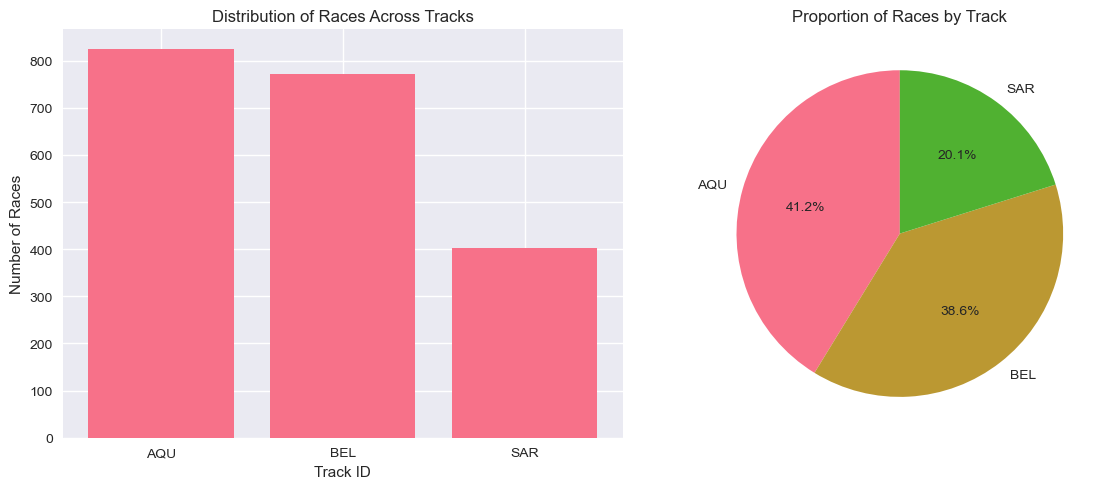

In [20]:
# Distribution of track_id in race table
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
track_counts = race_df['track_id'].value_counts()
plt.bar(track_counts.index, track_counts.values)
plt.title('Distribution of Races Across Tracks')
plt.xlabel('Track ID')
plt.ylabel('Number of Races')

plt.subplot(1, 2, 2)
# Create pie chart for better visualization of track distribution
plt.pie(track_counts.values, labels=track_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Races by Track')

plt.tight_layout()
plt.show()

# Reasoning: Understanding the distribution of races across tracks helps identify data imbalance
# and potential track-specific patterns that might affect performance analysis.

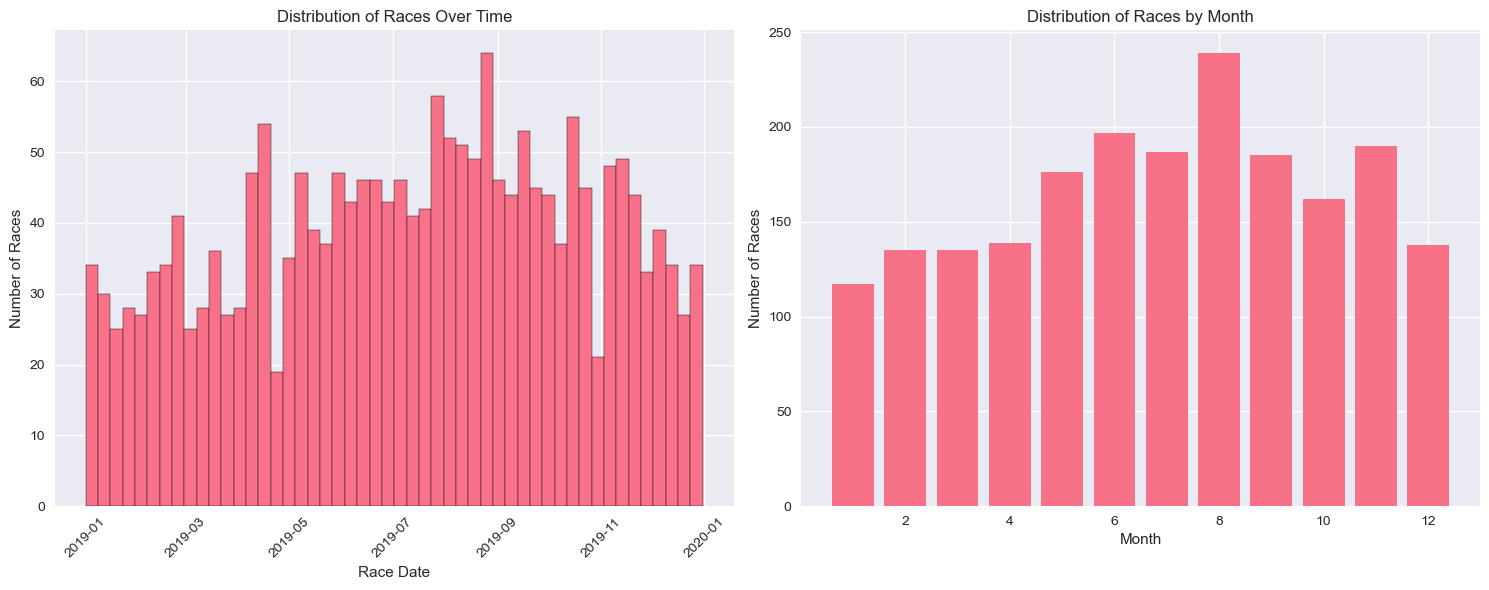

In [21]:
# Distribution of race dates
race_df['race_date'] = pd.to_datetime(race_df['race_date'])
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
race_df['race_date'].hist(bins=50, edgecolor='black')
plt.title('Distribution of Races Over Time')
plt.xlabel('Race Date')
plt.ylabel('Number of Races')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
# Group by month to see seasonal patterns
race_df['month'] = race_df['race_date'].dt.month
monthly_races = race_df['month'].value_counts().sort_index()
plt.bar(monthly_races.index, monthly_races.values)
plt.title('Distribution of Races by Month')
plt.xlabel('Month')
plt.ylabel('Number of Races')

plt.tight_layout()
plt.show()


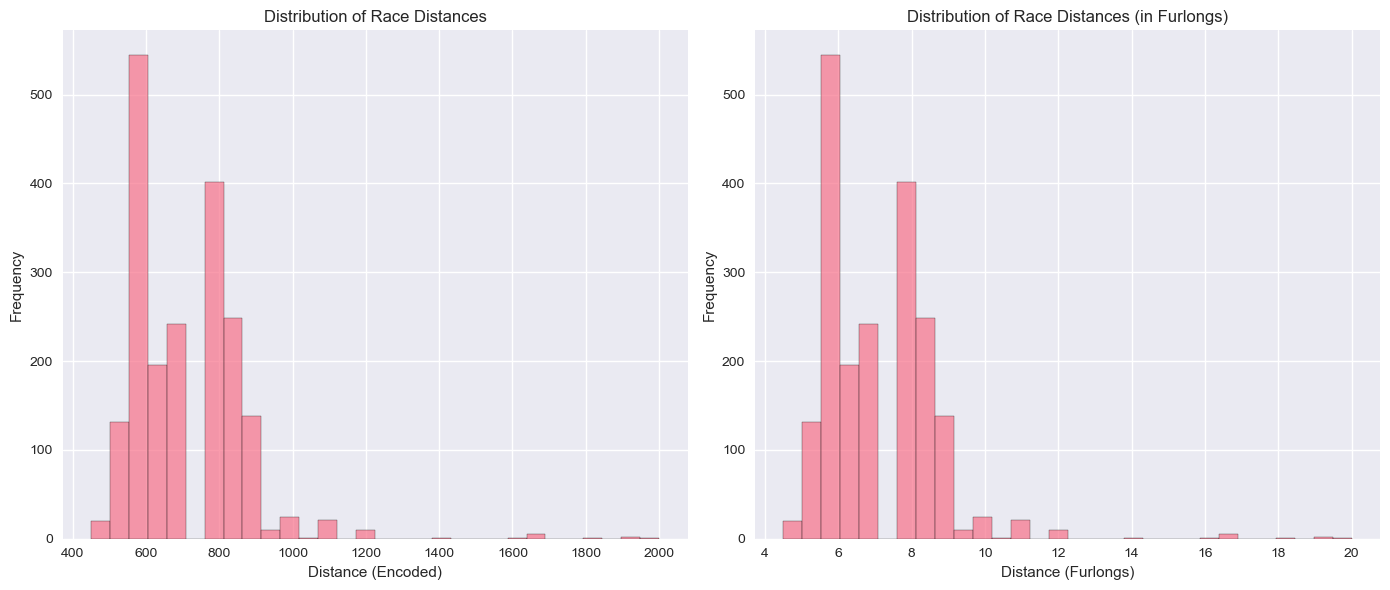

In [22]:
# Distribution of distance_id (race distance)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(race_df['distance_id'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Race Distances')
plt.xlabel('Distance (Encoded)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
# Convert furlongs for better understanding
distances_furlongs = race_df['distance_id'] / 100  # converting to furlongs
plt.hist(distances_furlongs, bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Race Distances (in Furlongs)')
plt.xlabel('Distance (Furlongs)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


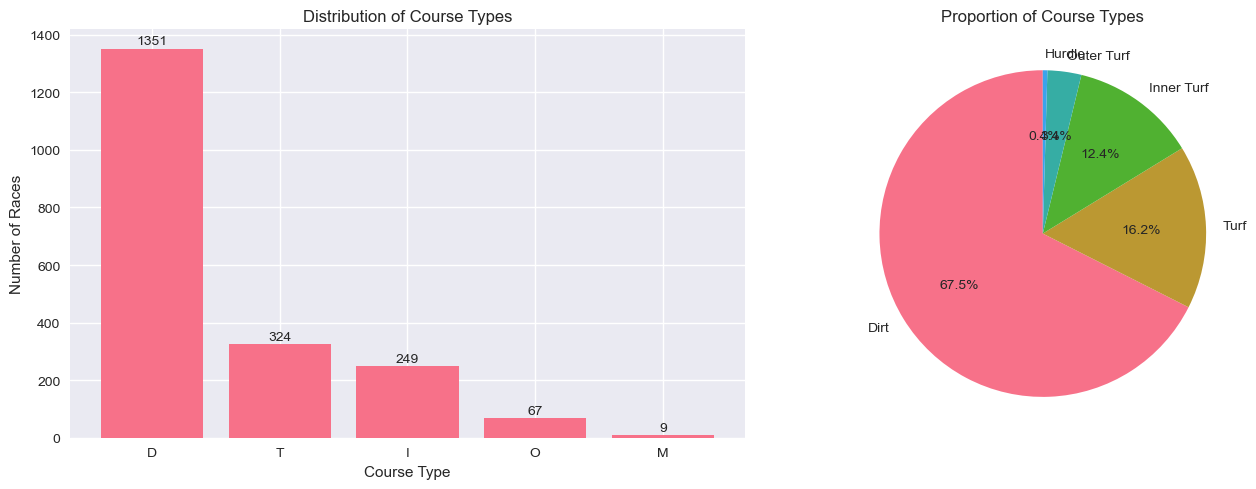

In [23]:
# Distribution of course_type
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
course_counts = race_df['course_type'].value_counts()
plt.bar(course_counts.index, course_counts.values)
plt.title('Distribution of Course Types')
plt.xlabel('Course Type')
plt.ylabel('Number of Races')
# Add labels to bars
for i, v in enumerate(course_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom')

plt.subplot(1, 2, 2)
plt.pie(course_counts.values, labels=['Dirt', 'Turf', 'Inner Turf', 'Outer Turf', 'Hurdle'], 
        autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Course Types')

plt.tight_layout()
plt.show()

# Reasoning: Course type (surface) significantly impacts racing strategies and horse performance.
# Dirt vs. turf races often require different skill sets from horses and jockeys.

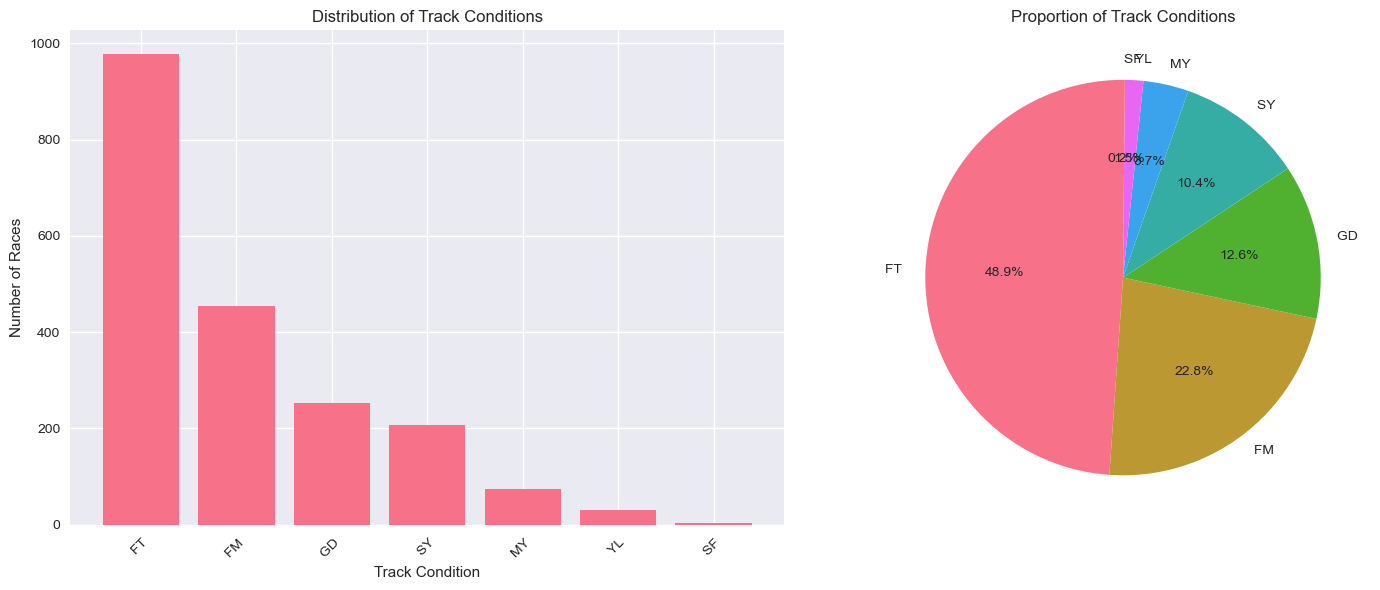

In [24]:
# Distribution of track_condition
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
condition_counts = race_df['track_condition'].value_counts()
plt.bar(range(len(condition_counts)), condition_counts.values)
plt.title('Distribution of Track Conditions')
plt.xlabel('Track Condition')
plt.ylabel('Number of Races')
plt.xticks(range(len(condition_counts)), condition_counts.index, rotation=45)

plt.subplot(1, 2, 2)
plt.pie(condition_counts.values, labels=condition_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Track Conditions')

plt.tight_layout()
plt.show()

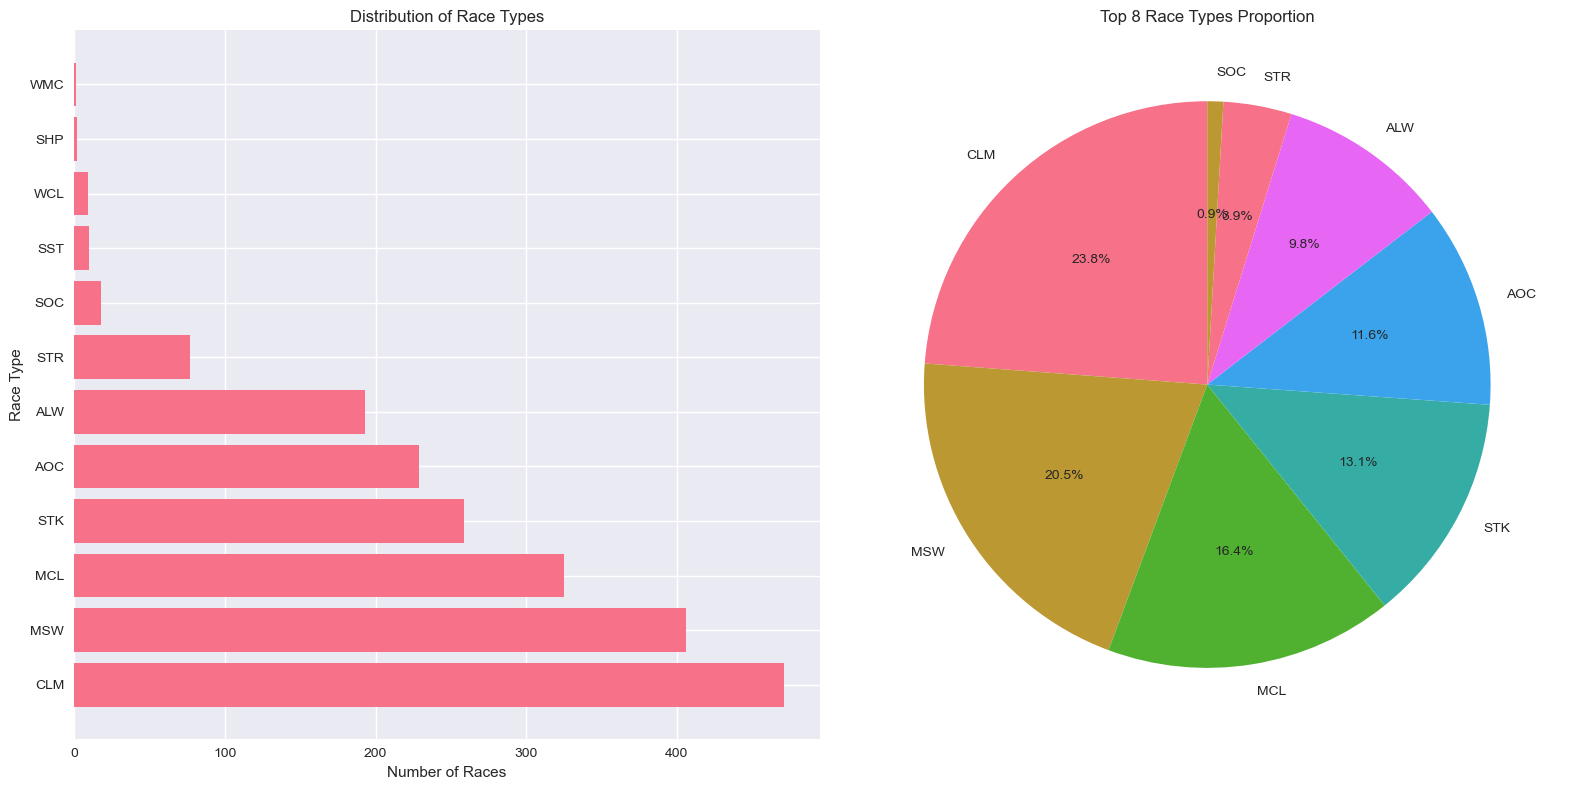

In [25]:
# Distribution of race_type
plt.figure(figsize=(16, 8))

race_type_counts = race_df['race_type'].value_counts()
plt.subplot(1, 2, 1)
plt.barh(range(len(race_type_counts)), race_type_counts.values)
plt.title('Distribution of Race Types')
plt.xlabel('Number of Races')
plt.ylabel('Race Type')
plt.yticks(range(len(race_type_counts)), race_type_counts.index)

plt.subplot(1, 2, 2)
plt.pie(race_type_counts.values[:8], labels=race_type_counts.index[:8], autopct='%1.1f%%', startangle=90)
plt.title('Top 8 Race Types Proportion')

plt.tight_layout()
plt.show()


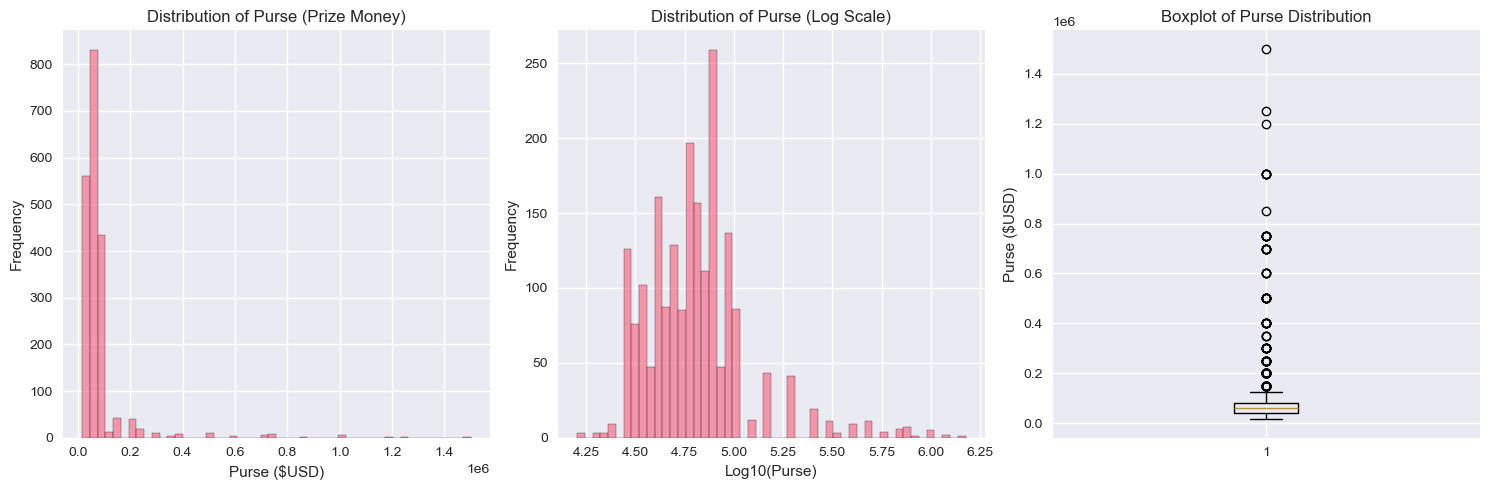

In [26]:
# Distribution of purse (prize money)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(race_df['purse'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Purse (Prize Money)')
plt.xlabel('Purse ($USD)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
# Log scale to better see the distribution
plt.hist(np.log10(race_df['purse']), bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Purse (Log Scale)')
plt.xlabel('Log10(Purse)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
# Box plot to show quartiles and outliers
plt.boxplot(race_df['purse'])
plt.title('Boxplot of Purse Distribution')
plt.ylabel('Purse ($USD)')

plt.tight_layout()
plt.show()


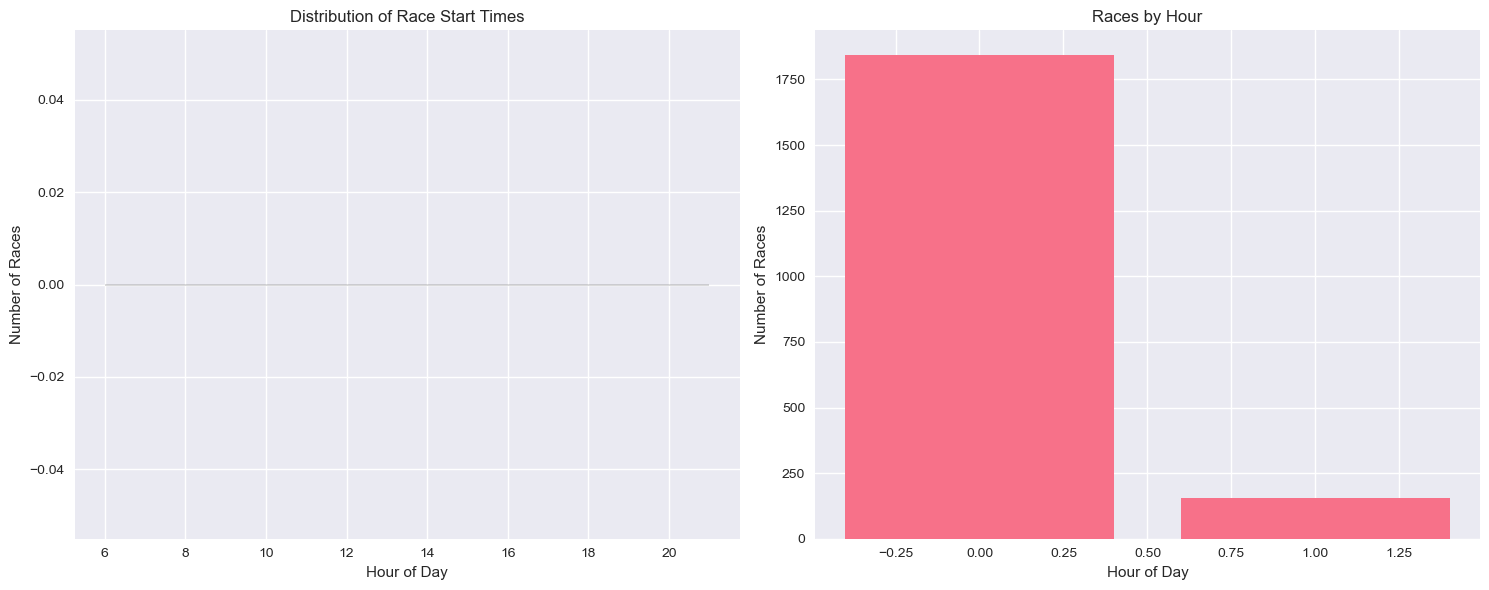

In [27]:
# Distribution of post_time (race start time)
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
# Convert post_time to proper time format
race_df['post_time_formatted'] = race_df['post_time'].astype(str).str.zfill(5)
race_df['hour'] = race_df['post_time_formatted'].str[:2].astype(int)
plt.hist(race_df['hour'], bins=range(6, 22), edgecolor='black', alpha=0.7)
plt.title('Distribution of Race Start Times')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Races')
plt.xticks(range(6, 21, 2))

plt.subplot(1, 2, 2)
# More detailed view of race start times
start_counts = race_df['hour'].value_counts().sort_index()
plt.bar(start_counts.index, start_counts.values)
plt.title('Races by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Races')

plt.tight_layout()
plt.show()


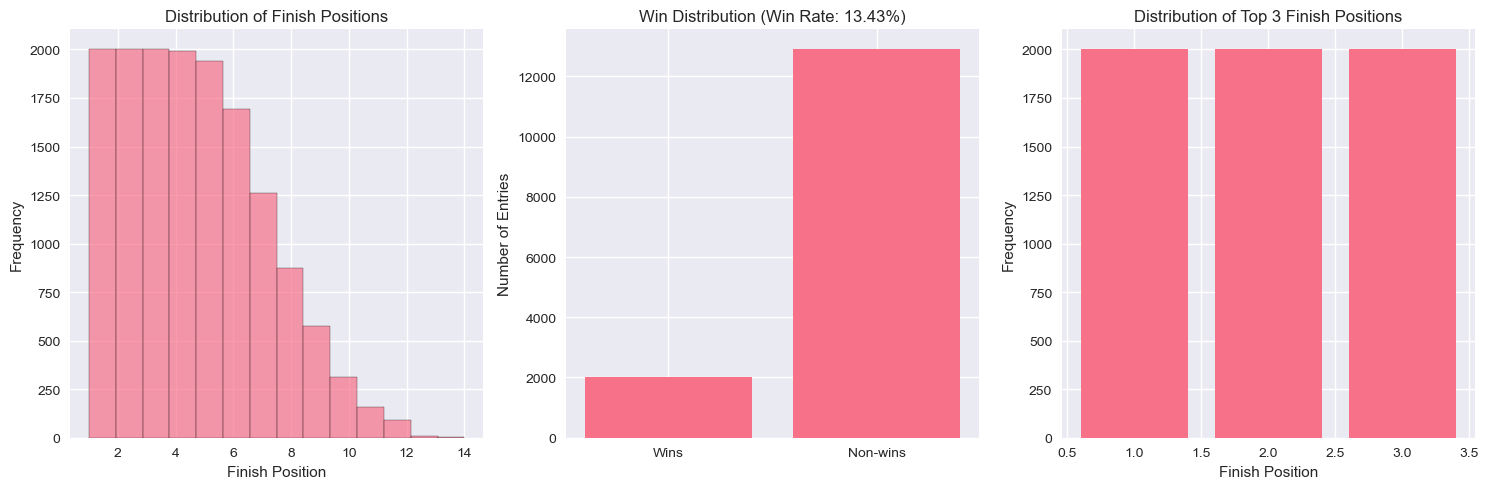

In [28]:
# Distribution of finish positions from start table
# Add position_at_finish to the complete analysis
start_df.columns = ['track_id', 'race_date', 'race_number', 'program_number', 'weight_carried', 
                    'jockey', 'odds', 'position_at_finish']

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(start_df['position_at_finish'], bins=start_df['position_at_finish'].max(), 
         edgecolor='black', alpha=0.7)
plt.title('Distribution of Finish Positions')
plt.xlabel('Finish Position')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
# Proportion of wins (position 1)
win_rate = (start_df['position_at_finish'] == 1).mean()
plt.bar(['Wins', 'Non-wins'], [(start_df['position_at_finish'] == 1).sum(), 
                                (start_df['position_at_finish'] != 1).sum()])
plt.title(f'Win Distribution (Win Rate: {win_rate:.2%})')
plt.ylabel('Number of Entries')

plt.subplot(1, 3, 3)
# Show top finish positions (1st, 2nd, 3rd)
top3_counts = start_df[start_df['position_at_finish'] <= 3]['position_at_finish'].value_counts().sort_index()
plt.bar(top3_counts.index, top3_counts.values)
plt.title('Distribution of Top 3 Finish Positions')
plt.xlabel('Finish Position')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


count    14914.000000
mean       120.453869
std          3.522064
min        110.000000
25%        118.000000
50%        120.000000
75%        122.000000
max        160.000000
Name: weight_carried, dtype: float64


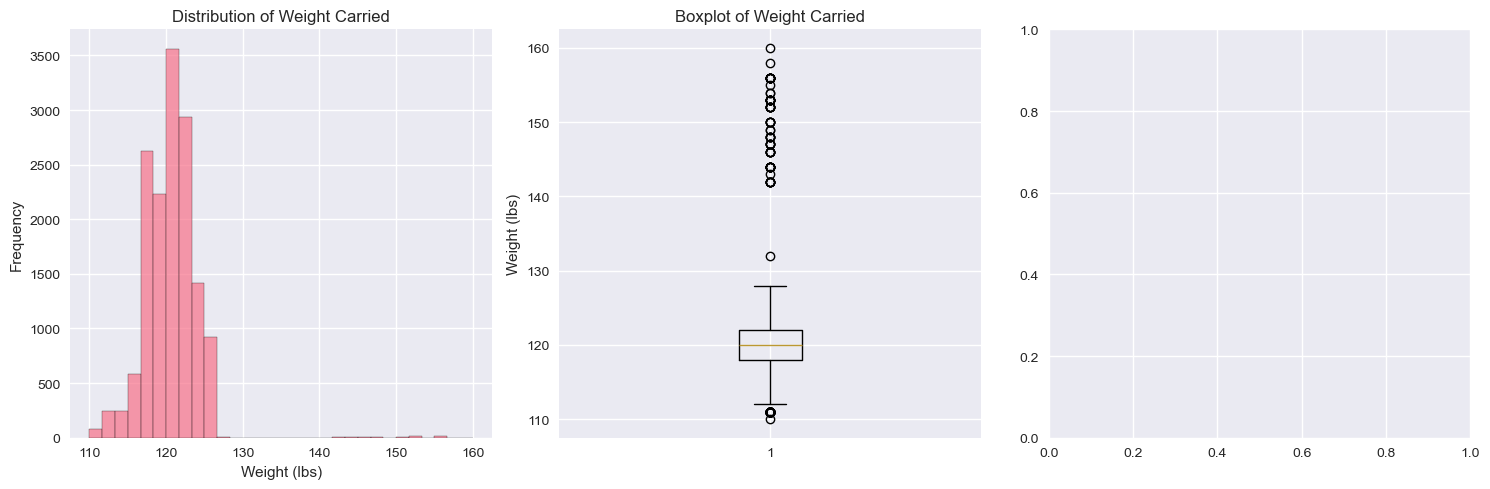

In [29]:
# Distribution of weight carried by horses
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(start_df['weight_carried'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Weight Carried')
plt.xlabel('Weight (lbs)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.boxplot(start_df['weight_carried'])
plt.title('Boxplot of Weight Carried')
plt.ylabel('Weight (lbs)')

plt.subplot(1, 3, 3)
# Check for specific weight classes
weight_summary = start_df['weight_carried'].describe()
print(weight_summary)

plt.tight_layout()
plt.show()

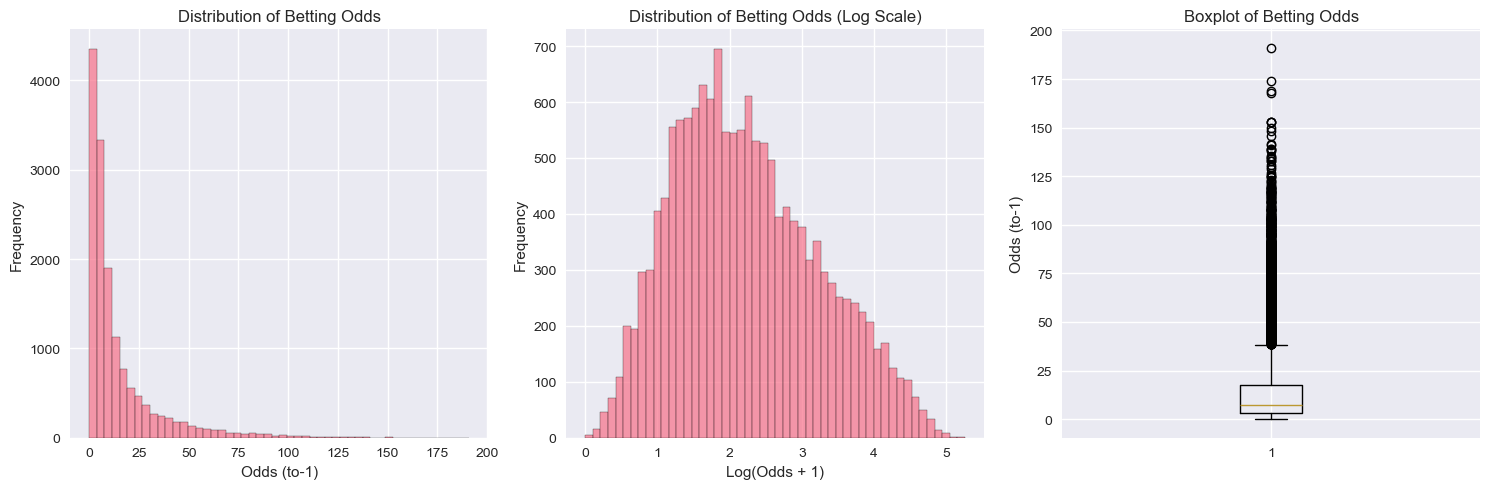

In [30]:
# Distribution of odds
# Odds are given as integers (e.g., 1280 means 12.8-1)
start_df['actual_odds'] = start_df['odds'] / 100  # Convert to actual odds

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(start_df['actual_odds'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Betting Odds')
plt.xlabel('Odds (to-1)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
# Log scale for better visualization of the wide range
plt.hist(np.log1p(start_df['actual_odds']), bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Betting Odds (Log Scale)')
plt.xlabel('Log(Odds + 1)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.boxplot(start_df['actual_odds'])
plt.title('Boxplot of Betting Odds')
plt.ylabel('Odds (to-1)')

plt.tight_layout()
plt.show()


## Bivariate Analysis

In this section, we'll explore relationships between pairs of variables to understand how different factors interact and influence performance.

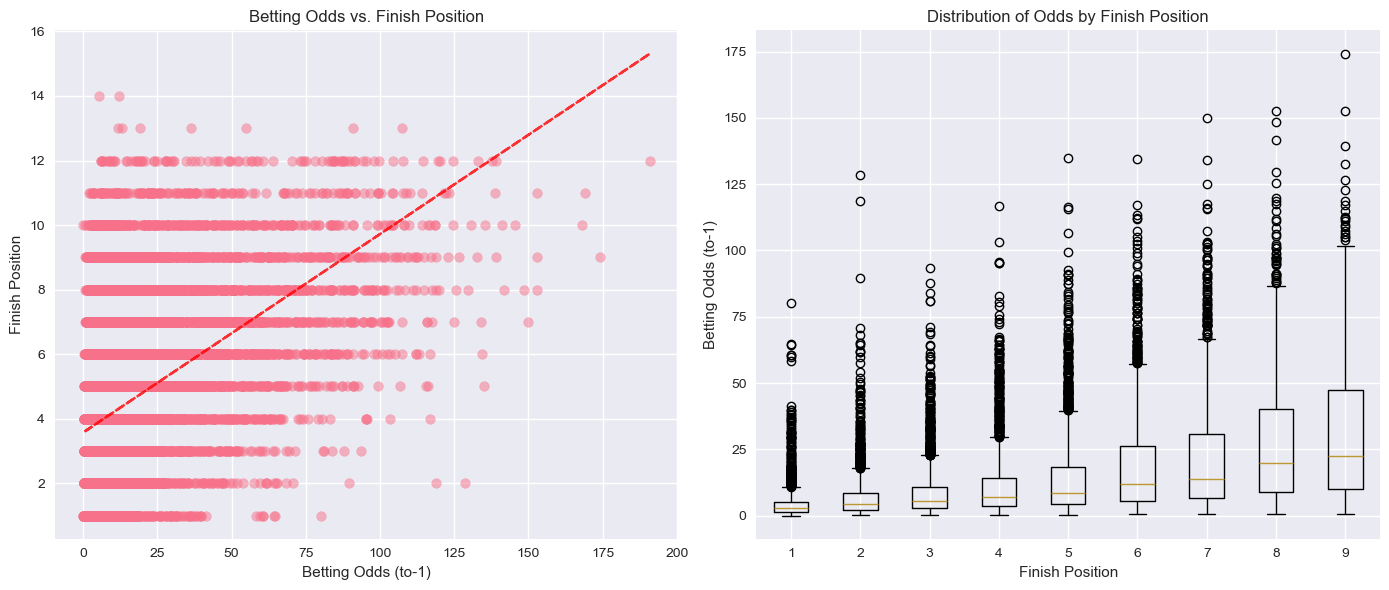

In [31]:
# Relationship between odds and finish position
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(start_df['actual_odds'], start_df['position_at_finish'], alpha=0.5)
plt.xlabel('Betting Odds (to-1)')
plt.ylabel('Finish Position')
plt.title('Betting Odds vs. Finish Position')
# Add trend line
z = np.polyfit(start_df['actual_odds'], start_df['position_at_finish'], 1)
p = np.poly1d(z)
plt.plot(start_df['actual_odds'], p(start_df['actual_odds']), "r--", alpha=0.8)

plt.subplot(1, 2, 2)
# Box plot to show distribution of odds by finish position
pos_odds_data = [start_df[start_df['position_at_finish'] == i]['actual_odds'] for i in range(1, min(10, start_df['position_at_finish'].max()+1))]
plt.boxplot(pos_odds_data, labels=range(1, len(pos_odds_data)+1))
plt.xlabel('Finish Position')
plt.ylabel('Betting Odds (to-1)')
plt.title('Distribution of Odds by Finish Position')

plt.tight_layout()
plt.show()


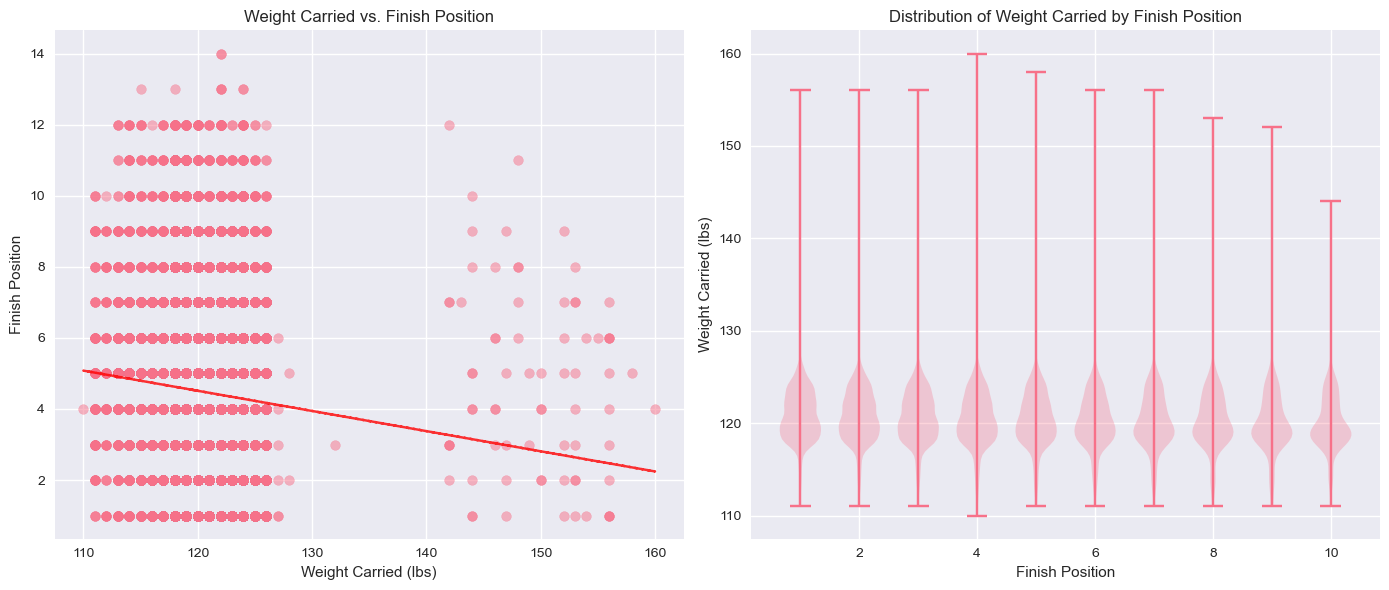

In [32]:
# Relationship between weight carried and finish position
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(start_df['weight_carried'], start_df['position_at_finish'], alpha=0.5)
plt.xlabel('Weight Carried (lbs)')
plt.ylabel('Finish Position')
plt.title('Weight Carried vs. Finish Position')
# Add trend line
z = np.polyfit(start_df['weight_carried'], start_df['position_at_finish'], 1)
p = np.poly1d(z)
plt.plot(start_df['weight_carried'], p(start_df['weight_carried']), "r--", alpha=0.8)

plt.subplot(1, 2, 2)
# Violin plot for better visualization of distribution
data_for_violin = []
positions = sorted(start_df['position_at_finish'].unique())[:10]  # Top 10 positions
for pos in positions:
    data_for_violin.append(start_df[start_df['position_at_finish'] == pos]['weight_carried'])

plt.violinplot(data_for_violin, positions=positions, widths=0.7)
plt.xlabel('Finish Position')
plt.ylabel('Weight Carried (lbs)')
plt.title('Distribution of Weight Carried by Finish Position')

plt.tight_layout()
plt.show()


In [33]:
# Strip trailing spaces
race_df['track_condition'] = race_df['track_condition'].str.strip()

# Standardize dates
race_df['race_date'] = pd.to_datetime(race_df['race_date'])
start_df['race_date'] = pd.to_datetime(start_df['race_date'])

# Confirm data types for race_number and track_id
race_df['race_number'] = race_df['race_number'].astype(str)
start_df['race_number'] = start_df['race_number'].astype(str)
race_df['track_id'] = race_df['track_id'].astype(str)
start_df['track_id'] = start_df['track_id'].astype(str)


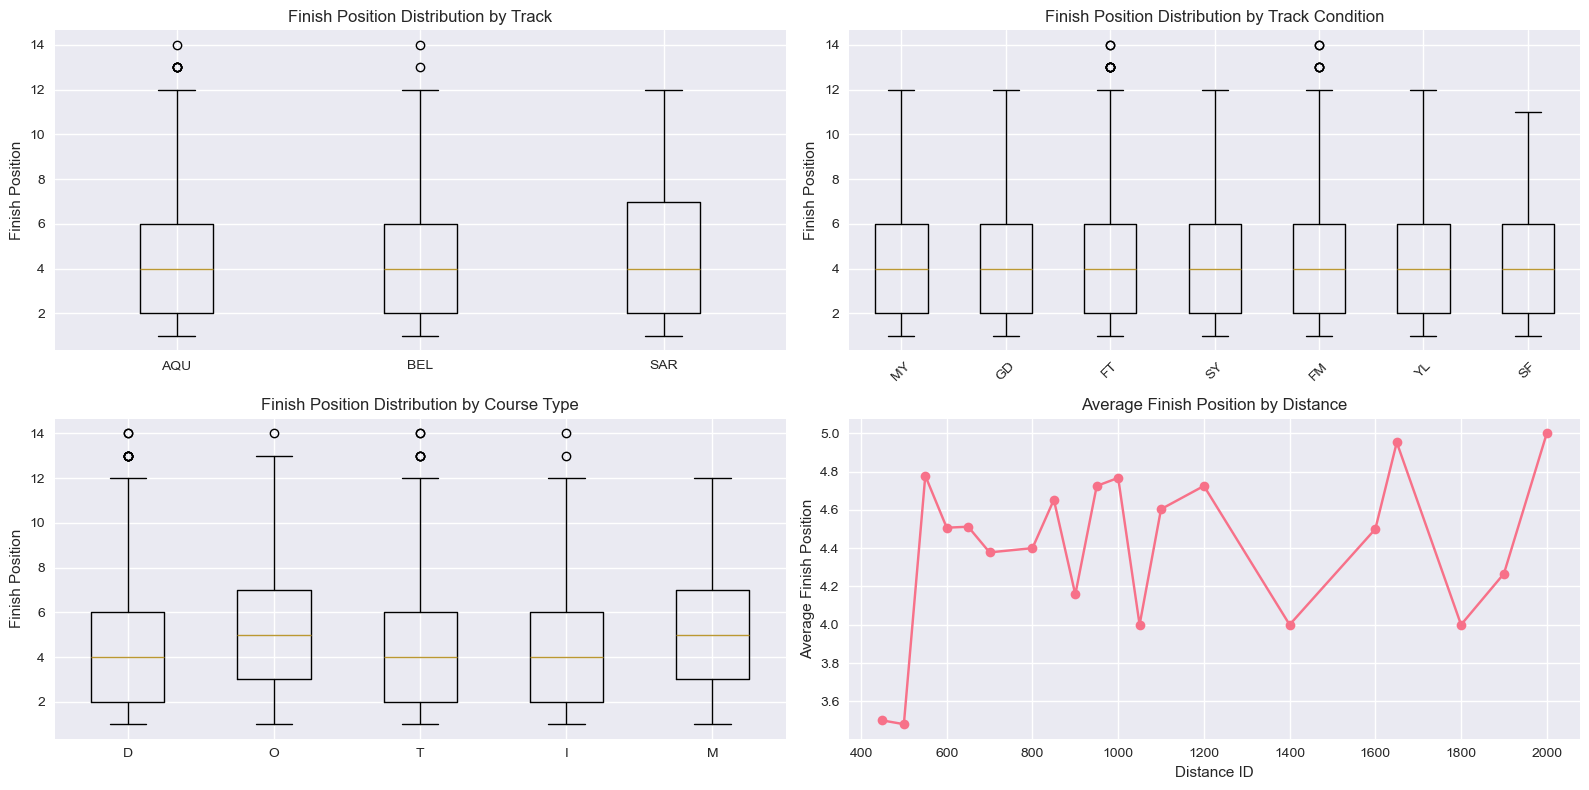

In [34]:
# Relationship between track condition and finish position
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
# Box plot of finish position by track
conditions = race_df['track_condition'].unique()
pos_by_condition = [start_df[start_df['track_id'] == track]['position_at_finish'] for track in ['AQU', 'BEL', 'SAR']]
plt.boxplot(pos_by_condition, labels=['AQU', 'BEL', 'SAR'])
plt.title('Finish Position Distribution by Track')
plt.ylabel('Finish Position')

plt.subplot(2, 2, 2)
# Box plot by track condition
condition_data = []
for cond in race_df['track_condition'].unique():
    if cond in ['FT', 'GD', 'SY', 'MY', 'FM', 'YL', 'SF']:
        # Get races with this condition
        races_with_cond = race_df[race_df['track_condition'] == cond]
        # Get corresponding start data
        mask = start_df['track_id'].isin(races_with_cond['track_id']) & start_df['race_date'].isin(races_with_cond['race_date']) & start_df['race_number'].isin(races_with_cond['race_number'])
        condition_data.append(start_df[mask]['position_at_finish'])

conds = [c for c in race_df['track_condition'].unique() if c in ['FT', 'GD', 'SY', 'MY', 'FM', 'YL', 'SF']]
plt.boxplot(condition_data, labels=conds)
plt.title('Finish Position Distribution by Track Condition')
plt.ylabel('Finish Position')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
# Relationship between course type and finish position
course_data = []
for course in race_df['course_type'].unique():
    if pd.notna(course):
        # Get races with this course type
        races_with_course = race_df[race_df['course_type'] == course]
        # Get corresponding start data
        mask = start_df['track_id'].isin(races_with_course['track_id']) & start_df['race_date'].isin(races_with_course['race_date']) &start_df['race_number'].isin(races_with_course['race_number'])
        course_data.append(start_df[mask]['position_at_finish'])

courses = [c for c in race_df['course_type'].unique() if pd.notna(c)]
plt.boxplot(course_data, labels=courses)
plt.title('Finish Position Distribution by Course Type')
plt.ylabel('Finish Position')

plt.subplot(2, 2, 4)
# Average finish position by distance
dist_finish = start_df.merge(race_df[['track_id', 'race_date', 'race_number', 'distance_id']], 
                             on=['track_id', 'race_date', 'race_number'])
dist_avg = dist_finish.groupby('distance_id')['position_at_finish'].mean().sort_index()
plt.plot(dist_avg.index, dist_avg.values, marker='o')
plt.title('Average Finish Position by Distance')
plt.xlabel('Distance ID')
plt.ylabel('Average Finish Position')

plt.tight_layout()
plt.show()

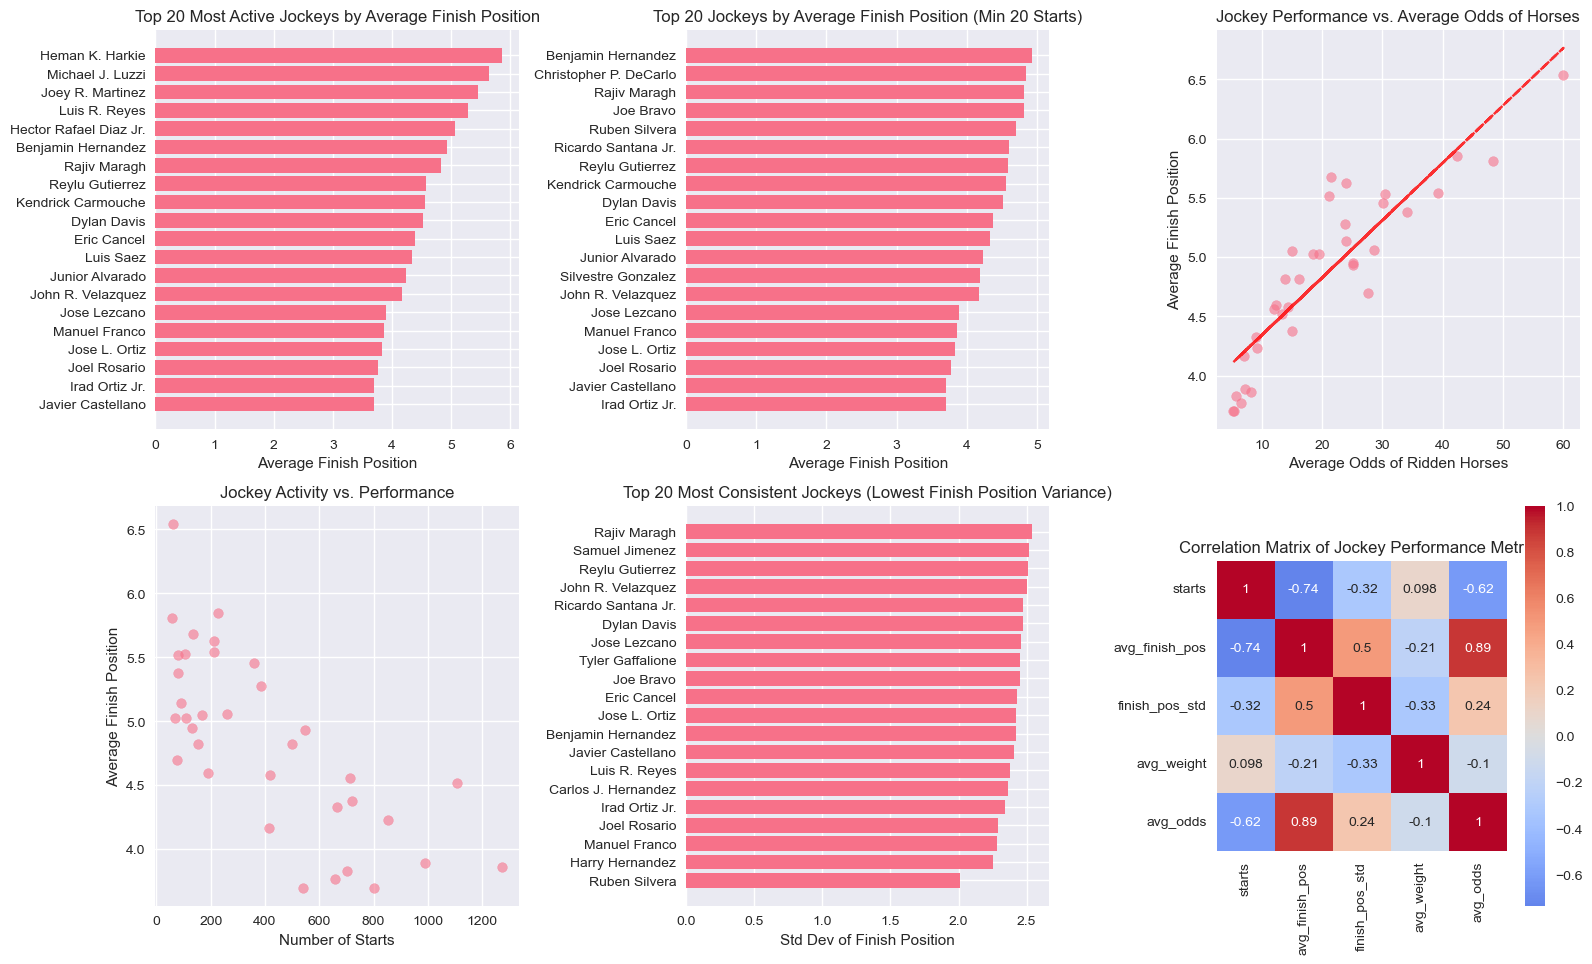

In [35]:
# Jockey performance analysis
jockey_stats = start_df.groupby('jockey').agg({
    'position_at_finish': ['count', 'mean', 'std'],
    'weight_carried': 'mean',
    'actual_odds': 'mean'
}).round(2)

# Flatten column names
jockey_stats.columns = ['_'.join(col).strip() for col in jockey_stats.columns]
jockey_stats = jockey_stats.rename(columns={
    'position_at_finish_count': 'starts',
    'position_at_finish_mean': 'avg_finish_pos',
    'position_at_finish_std': 'finish_pos_std',
    'weight_carried_mean': 'avg_weight',
    'actual_odds_mean': 'avg_odds'
})

# Filter for jockeys with at least 50 starts for reliability
active_jockeys = jockey_stats[jockey_stats['starts'] >= 50]

plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
# Top 20 jockeys by average finish position
top_jockeys = active_jockeys.nlargest(20, 'starts').sort_values('avg_finish_pos')
plt.barh(range(len(top_jockeys)), top_jockeys['avg_finish_pos'])
plt.yticks(range(len(top_jockeys)), top_jockeys.index)
plt.xlabel('Average Finish Position')
plt.title('Top 20 Most Active Jockeys by Average Finish Position')

plt.subplot(2, 3, 2)
# Jockeys with best average finish position (minimum 20 starts)
qualifying_jockeys = jockey_stats[jockey_stats['starts'] >= 20]
best_finish = qualifying_jockeys.nsmallest(20, 'avg_finish_pos')
plt.barh(range(len(best_finish)), best_finish['avg_finish_pos'])
plt.yticks(range(len(best_finish)), best_finish.index)
plt.xlabel('Average Finish Position')
plt.title('Top 20 Jockeys by Average Finish Position (Min 20 Starts)')

plt.subplot(2, 3, 3)
# Relationship between average odds horses and average finish position
plt.scatter(active_jockeys['avg_odds'], active_jockeys['avg_finish_pos'], alpha=0.6)
plt.xlabel('Average Odds of Ridden Horses')
plt.ylabel('Average Finish Position')
plt.title('Jockey Performance vs. Average Odds of Horses')
# Add trend line
z = np.polyfit(active_jockeys['avg_odds'], active_jockeys['avg_finish_pos'], 1)
p = np.poly1d(z)
plt.plot(active_jockeys['avg_odds'], p(active_jockeys['avg_odds']), "r--", alpha=0.8)

plt.subplot(2, 3, 4)
# Starts vs. Performance (scatter plot)
plt.scatter(active_jockeys['starts'], active_jockeys['avg_finish_pos'], alpha=0.6)
plt.xlabel('Number of Starts')
plt.ylabel('Average Finish Position')
plt.title('Jockey Activity vs. Performance')

plt.subplot(2, 3, 5)
# Consistency analysis - standard deviation of finish position
top_by_consistency = active_jockeys.nsmallest(20, 'finish_pos_std')
plt.barh(range(len(top_by_consistency)), top_by_consistency['finish_pos_std'])
plt.yticks(range(len(top_by_consistency)), top_by_consistency.index)
plt.xlabel('Std Dev of Finish Position')
plt.title('Top 20 Most Consistent Jockeys (Lowest Finish Position Variance)')

plt.subplot(2, 3, 6)
# Correlation between all jockey metrics
jockey_corr_data = active_jockeys[['starts', 'avg_finish_pos', 'finish_pos_std', 'avg_weight', 'avg_odds']]
corr_matrix = jockey_corr_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix of Jockey Performance Metrics')

plt.tight_layout()
plt.show()


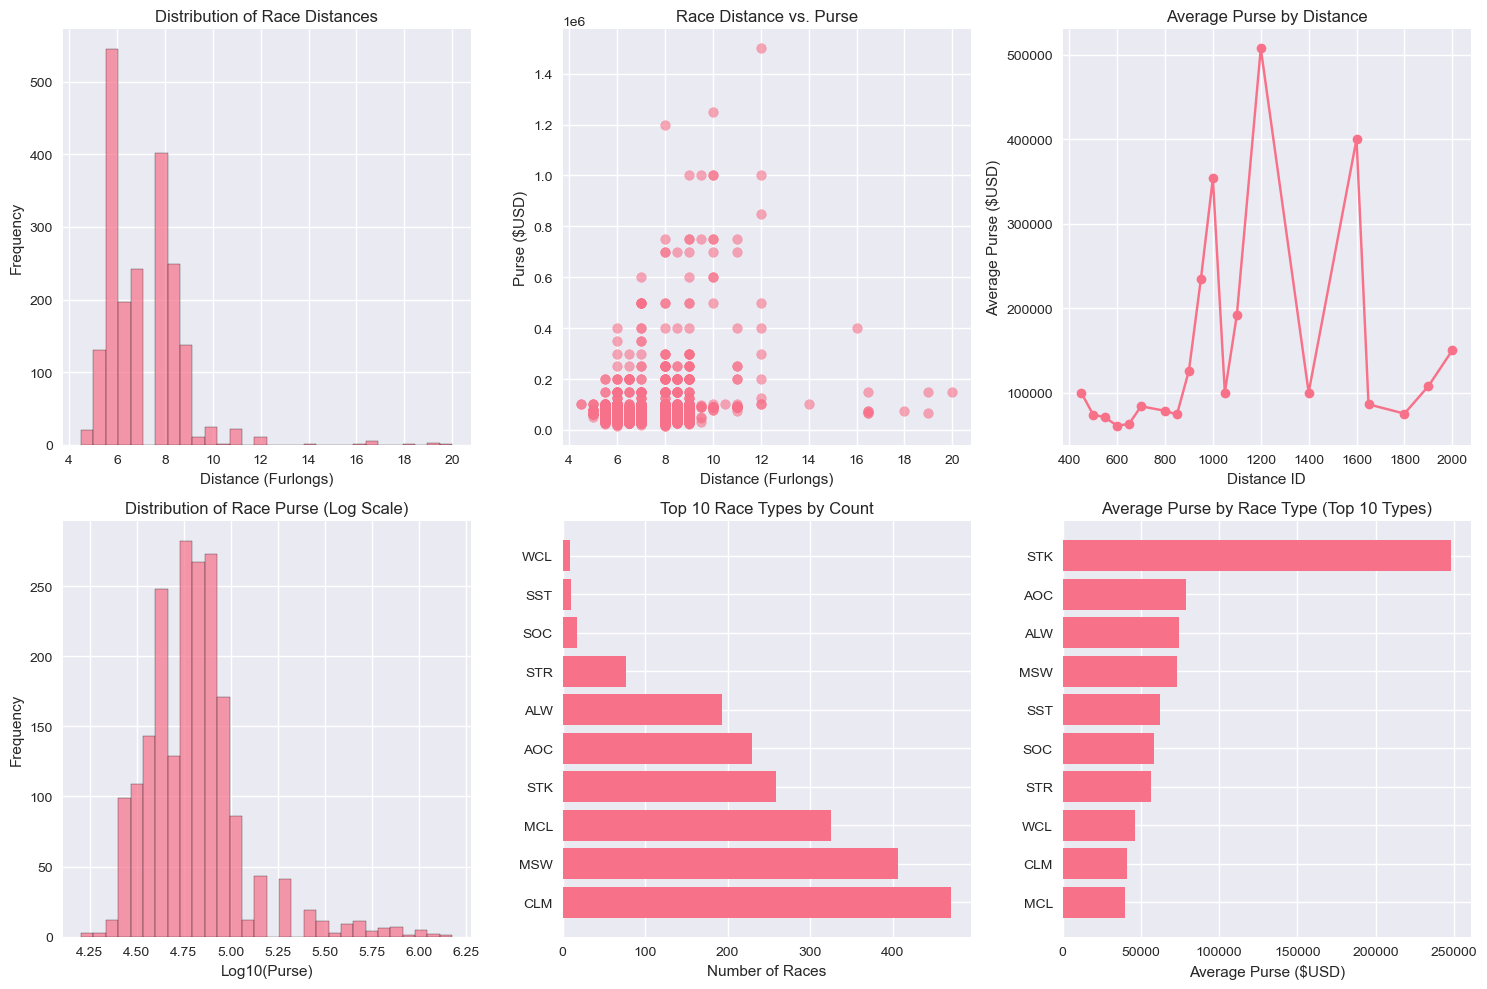

In [36]:
# Distance and purse analysis
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
# Distribution of distances in furlongs
distances_furlongs = race_df['distance_id'] / 100
plt.hist(distances_furlongs, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Distance (Furlongs)')
plt.ylabel('Frequency')
plt.title('Distribution of Race Distances')

plt.subplot(2, 3, 2)
# Distance vs. Purse
plt.scatter(distances_furlongs, race_df['purse'], alpha=0.6)
plt.xlabel('Distance (Furlongs)')
plt.ylabel('Purse ($USD)')
plt.title('Race Distance vs. Purse')

plt.subplot(2, 3, 3)
# Average purse by distance
dist_purse = race_df.groupby('distance_id')['purse'].mean()
plt.plot(dist_purse.index, dist_purse.values, marker='o')
plt.xlabel('Distance ID')
plt.ylabel('Average Purse ($USD)')
plt.title('Average Purse by Distance')

plt.subplot(2, 3, 4)
# Purse distribution
plt.hist(np.log10(race_df['purse']), bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Log10(Purse)')
plt.ylabel('Frequency')
plt.title('Distribution of Race Purse (Log Scale)')

plt.subplot(2, 3, 5)
# Race type distribution
race_type_counts = race_df['race_type'].value_counts().head(10)
plt.barh(range(len(race_type_counts)), race_type_counts.values)
plt.yticks(range(len(race_type_counts)), race_type_counts.index)
plt.xlabel('Number of Races')
plt.title('Top 10 Race Types by Count')

plt.subplot(2, 3, 6)
# Race type vs. average purse
top_race_types = race_df['race_type'].value_counts().head(10).index
avg_purse_by_type = race_df[race_df['race_type'].isin(top_race_types)].groupby('race_type')['purse'].mean().sort_values(ascending=True)
plt.barh(range(len(avg_purse_by_type)), avg_purse_by_type.values)
plt.yticks(range(len(avg_purse_by_type)), avg_purse_by_type.index)
plt.xlabel('Average Purse ($USD)')
plt.title('Average Purse by Race Type (Top 10 Types)')

plt.tight_layout()
plt.show()


## Geospatial Analysis <a id='geospatial'></a>

In this section, we'll analyze the GPS tracking data to understand racing trajectories, speeds, and path efficiency.

In [37]:
# Explore the structure of the tracking data
print("Tracking data shape:", tracking_df.shape)
print("\nFirst few rows of tracking data:")
tracking_df.head()

Tracking data shape: (5228430, 7)

First few rows of tracking data:


,track_id,race_date,race_number,program_number,trakus_index,latitude,longitude
0,AQU,2019-01-01,9,6,72,40.672902,-73.827607
1,AQU,2019-01-01,9,6,73,40.672946,-73.827587
2,AQU,2019-01-01,9,6,74,40.672990,-73.827568
3,AQU,2019-01-01,9,6,63,40.672510,-73.827781
4,AQU,2019-01-01,9,6,64,40.672553,-73.827762


In [38]:
# Basic statistics for tracking data
print("\nTracking data info:")
tracking_df.info()


Tracking data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5228430 entries, 0 to 5228429
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   track_id        object 
 1   race_date       object 
 2   race_number     int64  
 3   program_number  object 
 4   trakus_index    int64  
 5   latitude        float64
 6   longitude       float64
dtypes: float64(2), int64(2), object(3)
memory usage: 279.2+ MB


In [39]:
# Check for unique races in tracking data
unique_races_track = tracking_df.groupby(['track_id', 'race_date', 'race_number']).size().reset_index(name='points')
print(f"Number of unique races in tracking data: {len(unique_races_track)}")
print(f"Points per race - Min: {unique_races_track['points'].min()}, Max: {unique_races_track['points'].max()}, Mean: {unique_races_track['points'].mean():.2f}")

Number of unique races in tracking data: 2000
Points per race - Min: 774, Max: 9862, Mean: 2614.22


In [40]:
# Sample a few races to visualize trajectories
# See what tracks we have in the tracking data
print("Tracks in tracking data:", tracking_df['track_id'].unique())

# Look at a single race for trajectory visualization
sample_race = tracking_df[(tracking_df['track_id'] == 'AQU')].head(5000)  # Limit for visualization

# Get a specific race with multiple horses
if len(sample_race) > 0:
    first_race_date = sample_race.iloc[0]['race_date']
    first_race_num = sample_race.iloc[0]['race_number']
    
    race_data = tracking_df[
        (tracking_df['track_id'] == 'AQU') &
        (tracking_df['race_date'] == first_race_date) &
        (tracking_df['race_number'] == first_race_num)
    ]
    
    print(f"Sample race data - Track: AQU, Date: {first_race_date}, Race #: {first_race_num}")
    print(f"Number of tracking points: {len(race_data)}")
    print(f"Number of horses: {race_data['program_number'].nunique()}")

Tracks in tracking data: ['AQU' 'BEL' 'SAR']
Sample race data - Track: AQU, Date: 2019-01-01, Race #: 9
Number of tracking points: 2673
Number of horses: 9


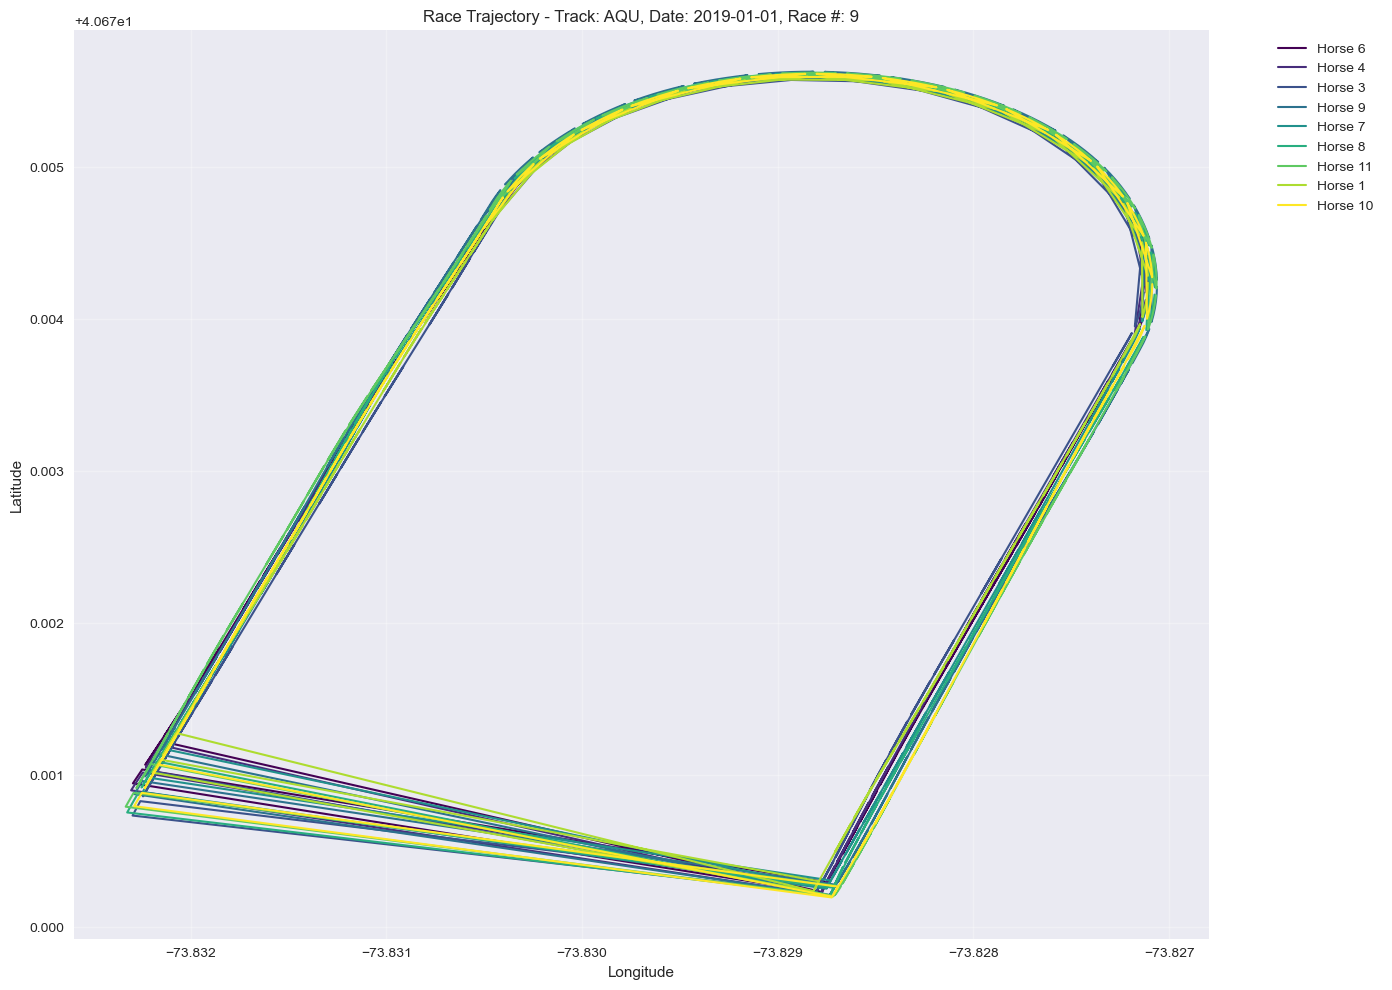

In [41]:
# Visualize sample race trajectories
if len(race_data) > 0:
    plt.figure(figsize=(14, 10))
    
    # Plot all horses in the race
    unique_horses = race_data['program_number'].unique()
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_horses)))
    
    for i, horse in enumerate(unique_horses[:10]):  # Limit to first 10 horses for clarity
        horse_data = race_data[race_data['program_number'] == horse]
        plt.plot(horse_data['longitude'], horse_data['latitude'], 
                label=f'Horse {horse}', color=colors[i], linewidth=1.5)
    
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Race Trajectory - Track: AQU, Date: {first_race_date}, Race #: {first_race_num}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Reasoning: Visualizing race trajectories helps understand path efficiency, 
    # positioning tactics, and how horses navigate the track during races.
    # Expected Outcome: Different horses may take different paths around the track,
    # with some taking the inside (shorter path) and others taking outside positions.
    # These path choices can significantly impact performance, especially in tight races.

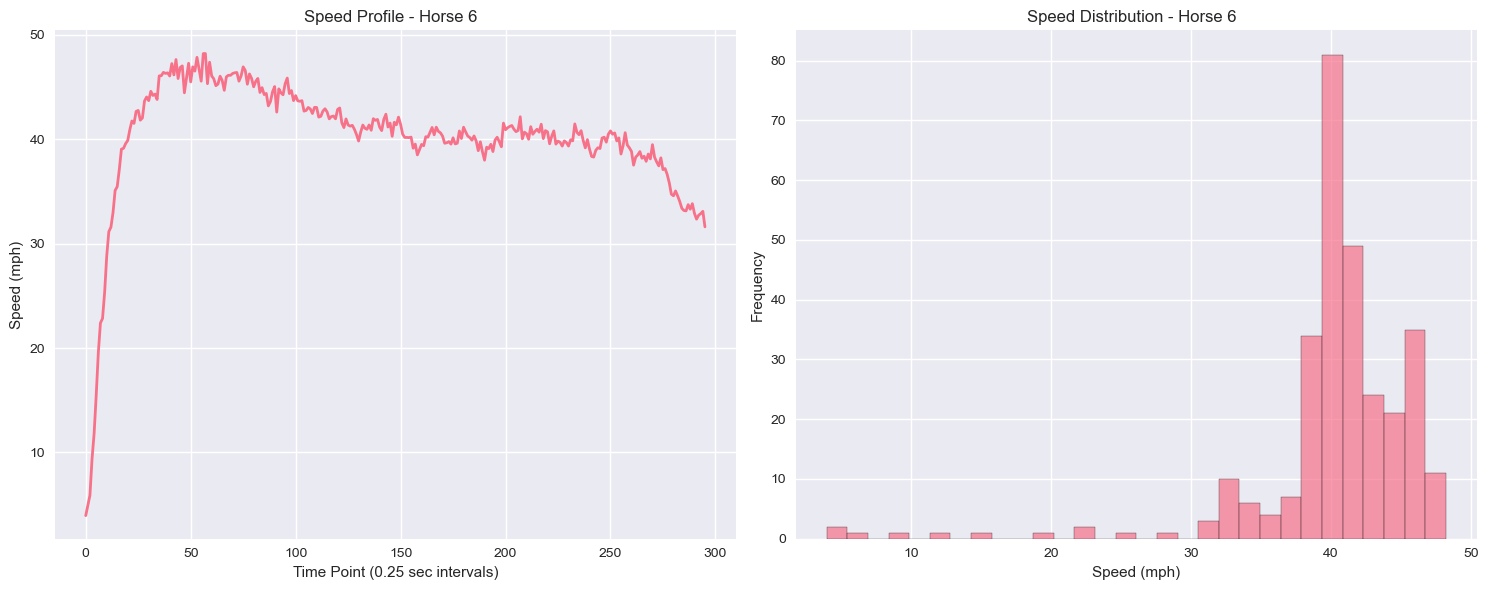

Sample horse 6   statistics:
Max speed: 48.21 mph
Average speed: 40.21 mph
Min speed: 3.95 mph


In [42]:
# Calculate speed from GPS coordinates for a sample race
# Note: This requires calculating distances between consecutive points and time differences
# Since we know trakus_index is collected every 0.25 seconds, we can use that for time

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    Returns distance in feet
    """
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1 
    dlon = lon2 - lon1 
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a)) 
    r = 3956 * 5280 # Radius of earth in feet
    return c * r

# Calculate speed for a single sample horse
if len(race_data) > 1:
    sample_horse = race_data['program_number'].iloc[0]
    horse_track = race_data[race_data['program_number'] == sample_horse].sort_values('trakus_index')
    
    # Calculate distance between consecutive points
    distances = []
    for i in range(1, len(horse_track)):
        dist = haversine_distance(horse_track.iloc[i-1]['latitude'], 
                                 horse_track.iloc[i-1]['longitude'],
                                 horse_track.iloc[i]['latitude'], 
                                 horse_track.iloc[i]['longitude'])
        distances.append(dist)
    
    # Calculate speed (distance in feet / time in seconds)
    # Since trakus_index records every 0.25 seconds, time interval is 0.25 seconds
    speeds = [d/0.25 for d in distances]  # feet per second
    speeds_mph = [s*3600/5280 for s in speeds]  # convert to miles per hour
    
    # Plot speed over time
    plt.figure(figsize=(15, 6))
    
    plt.subplot(1, 2, 1)
    time_points = list(range(len(speeds_mph)))
    plt.plot(time_points, speeds_mph, linewidth=2)
    plt.xlabel('Time Point (0.25 sec intervals)')
    plt.ylabel('Speed (mph)')
    plt.title(f'Speed Profile - Horse {sample_horse}')
    
    plt.subplot(1, 2, 2)
    plt.hist(speeds_mph, bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel('Speed (mph)')
    plt.ylabel('Frequency')
    plt.title(f'Speed Distribution - Horse {sample_horse}')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Sample horse {sample_horse} statistics:")
    print(f"Max speed: {max(speeds_mph):.2f} mph")
    print(f"Average speed: {np.mean(speeds_mph):.2f} mph")
    print(f"Min speed: {min(speeds_mph):.2f} mph")
    
    # Reasoning: Speed analysis helps understand how horses distribute their effort
    # throughout the race. Some horses may have consistent speeds, while others
    # may rate early and finish strongly (closers) or set the pace and fade (speed horses).
    # Expected Outcome: Speed patterns will vary by horse and race strategy - front-runners
    # will have higher early speeds that taper off, while closers will have lower early
    # speeds that increase later in the race.

## Feature Engineering <a id='feature_engineering'></a>

In this section, we'll create new features from the existing data to enhance our analysis and provide more insights.

In [43]:
# Check original columns in input dataframes
print("race_df columns:", race_df.columns.tolist())
print("start_df columns:", start_df.columns.tolist())

# Check initial data types
print("\nrace_df dtypes:\n", race_df.dtypes)
print("\nstart_df dtypes:\n", start_df.dtypes)

# Check sample values for key columns used in merge/join
print("\nrace_df['track_id'] sample:\n", race_df['track_id'].unique()[:5])
print("\nstart_df['track_id'] sample:\n", start_df['track_id'].unique()[:5])
print("\nrace_df['race_date'] sample:\n", race_df['race_date'].unique()[:5])
print("\nstart_df['race_date'] sample:\n", start_df['race_date'].unique()[:5])
print("\nrace_df['race_number'] sample:\n", race_df['race_number'].unique()[:5])
print("\nstart_df['race_number'] sample:\n", start_df['race_number'].unique()[:5])

# If you renamed start_df columns, check them post rename
if 'start_df_renamed' in locals():
    print("\nstart_df_renamed columns:", start_df_renamed.columns.tolist())

# Try merging and check the result shape and a few samples
try:
    if 'position_at_finish' not in complete_df.columns:
        complete_df = race_df.merge(start_df_renamed, on=['track_id', 'race_date', 'race_number'], how='inner')
    print("\nMerged complete_df shape:", complete_df.shape)
    print("Merged complete_df sample:\n", complete_df.head())
except Exception as e:
    print("\nMerge failed with exception:", e)

# Check for duplicates or missing merge keys
print("\nNumber of duplicates in race_df (key columns):", race_df.duplicated(['track_id', 'race_date', 'race_number']).sum())
print("Number of duplicates in start_df (key columns):", start_df.duplicated(['track_id', 'race_date', 'race_number']).sum())
print("\nNumber of nulls in race_df key columns:\n", race_df[['track_id', 'race_date', 'race_number']].isnull().sum())
print("\nNumber of nulls in start_df key columns:\n", start_df[['track_id', 'race_date', 'race_number']].isnull().sum())


race_df columns: ['track_id', 'race_date', 'race_number', 'distance_id', 'course_type', 'track_condition', 'run_up_distance', 'race_type', 'purse', 'post_time', 'month', 'post_time_formatted', 'hour']
start_df columns: ['track_id', 'race_date', 'race_number', 'program_number', 'weight_carried', 'jockey', 'odds', 'position_at_finish', 'actual_odds']

race_df dtypes:
 track_id                       object
race_date              datetime64[ns]
race_number                    object
distance_id                     int64
course_type                    object
track_condition                object
run_up_distance                 int64
race_type                      object
purse                           int64
post_time                       int64
month                           int32
post_time_formatted            object
hour                            int64
dtype: object

start_df dtypes:
 track_id                      object
race_date             datetime64[ns]
race_number                   

In [44]:
# Clean track_condition trailing spaces
race_df['track_condition'] = race_df['track_condition'].str.strip()

# Rename and reorder start_df columns properly for merge
start_df_renamed = start_df.rename(columns={
    'program_number': 'program_number',
    'weight_carried': 'weight_carried',
    'jockey': 'jockey',
    'odds': 'odds',
    'position_at_finish': 'position_at_finish'
})

# Drop duplicates in start_df if any exact duplicates on keys + program_number exist
start_df_renamed = start_df_renamed.drop_duplicates(subset=['track_id', 'race_date', 'race_number', 'program_number'])

# Perform merge with explicit inner join
complete_df = race_df.merge(start_df_renamed, 
                           on=['track_id', 'race_date', 'race_number'], how='inner')

# After merge, convert data types where needed
complete_df['program_number'] = complete_df['program_number'].astype(str)
complete_df['weight_carried'] = complete_df['weight_carried'].astype(int)
complete_df['position_at_finish'] = complete_df['position_at_finish'].astype(int)

# Verify final dataframe
print("Merged complete_df shape:", complete_df.shape)
print(complete_df.head())



Merged complete_df shape: (14914, 19)
  track_id  race_date race_number  distance_id course_type track_condition  \
0      AQU 2019-01-01           1          650           D              MY   
1      AQU 2019-01-01           1          650           D              MY   
2      AQU 2019-01-01           1          650           D              MY   
3      AQU 2019-01-01           1          650           D              MY   
4      AQU 2019-01-01           2          600           D              MY   

   run_up_distance race_type  purse  post_time  month post_time_formatted  \
0               36       AOC  80000       1220      1               01220   
1               36       AOC  80000       1220      1               01220   
2               36       AOC  80000       1220      1               01220   
3               36       AOC  80000       1220      1               01220   
4               48       MCL  41000       1250      1               01250   

   hour program_number  weight

In [45]:
# Create additional derived features
complete_df['race_date'] = pd.to_datetime(complete_df['race_date'])
complete_df['day_of_week'] = complete_df['race_date'].dt.dayofweek
complete_df['month'] = complete_df['race_date'].dt.month
complete_df['is_weekend'] = complete_df['day_of_week'].isin([5, 6]).astype(int)  # Sat=5, Sun=6
complete_df['odds_decimal'] = complete_df['odds'] / 100
complete_df['distance_furlongs'] = complete_df['distance_id'] / 100

# Convert post_time to hour
complete_df['post_time_str'] = complete_df['post_time'].astype(str).str.zfill(5)
complete_df['race_hour'] = complete_df['post_time_str'].str[:2].astype(int)

# Calculate track-specific statistics
track_stats = complete_df.groupby('track_id').agg({
    'position_at_finish': ['mean', 'std'],
    'weight_carried': 'mean',
    'odds_decimal': 'mean'
}).round(2)

track_stats.columns = ['_'.join(col).strip() for col in track_stats.columns]
track_stats = track_stats.rename(columns={
    'position_at_finish_mean': 'track_avg_finish',
    'position_at_finish_std': 'track_finish_std',
    'weight_carried_mean': 'track_avg_weight',
    'odds_decimal_mean': 'track_avg_odds'
})
print("Track-specific statistics:")
print(track_stats)

Track-specific statistics:
          track_avg_finish  track_finish_std  track_avg_weight  track_avg_odds
track_id                                                                      
AQU                   4.52              2.60            120.30           16.51
BEL                   4.35              2.50            120.32           13.66
SAR                   4.67              2.63            120.98           13.64


In [46]:
# Calculate jockey-specific statistics
jockey_performance = complete_df.groupby('jockey').agg({
    'position_at_finish': ['count', 'mean'],
    'odds_decimal': 'mean',
    'weight_carried': 'mean'
}).round(2)

jockey_performance.columns = ['_'.join(col).strip() for col in jockey_performance.columns]
jockey_performance = jockey_performance.rename(columns={
    'position_at_finish_count': 'jockey_starts',
    'position_at_finish_mean': 'jockey_avg_finish',
    'odds_decimal_mean': 'jockey_avg_odds',
    'weight_carried_mean': 'jockey_avg_weight'
})

# Add jockey stats back to the main dataset
complete_df = complete_df.merge(jockey_performance, left_on='jockey', right_index=True, how='left')

# Show top performing jockeys
top_jockeys_by_finish = jockey_performance[jockey_performance['jockey_starts'] >= 20].nsmallest(10, 'jockey_avg_finish')
print("Top 10 jockeys by average finish position (min 20 starts):")
print(top_jockeys_by_finish[['jockey_avg_finish', 'jockey_starts']])

Top 10 jockeys by average finish position (min 20 starts):
                    jockey_avg_finish  jockey_starts
jockey                                              
Irad Ortiz Jr.                   3.70            802
Javier Castellano                3.70            541
Joel Rosario                     3.77            657
Jose L. Ortiz                    3.83            702
Manuel Franco                    3.86           1274
Jose Lezcano                     3.89            990
John R. Velazquez                4.17            413
Silvestre Gonzalez               4.19             26
Junior Alvarado                  4.23            852
Luis Saez                        4.33            666


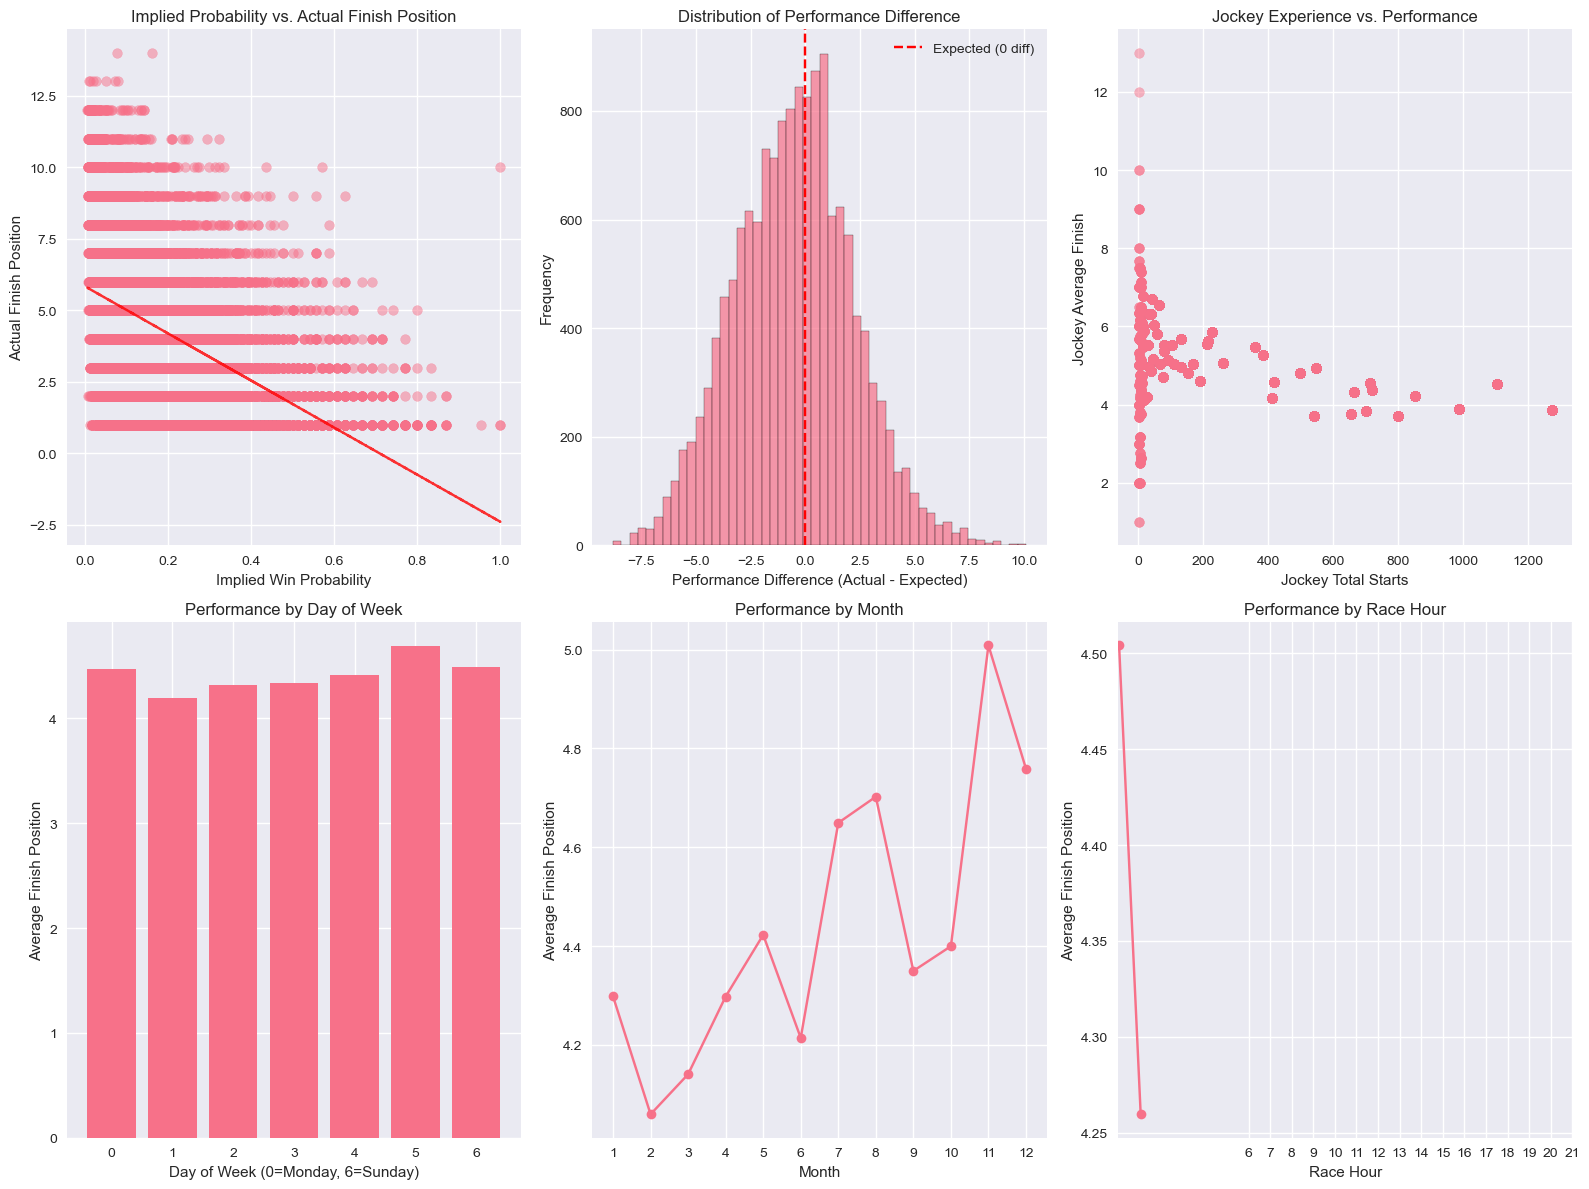

In [47]:
# Calculate expected vs actual performance
# Convert odds to probability
complete_df['implied_prob'] = 1 / (complete_df['odds_decimal'] + 1)

# Create a simple model for expected finish position
# Lower odds (favorites) should have lower expected finish positions
complete_df['expected_finish'] = complete_df['odds_decimal'].rank(pct=True) * 10  # Scale to approximately 1-10 range

# Calculate performance difference
complete_df['perf_diff'] = complete_df['position_at_finish'] - complete_df['expected_finish']

# Visualize the new features
plt.figure(figsize=(16, 12))

plt.subplot(2, 3, 1)
plt.scatter(complete_df['implied_prob'], complete_df['position_at_finish'], alpha=0.5)
plt.xlabel('Implied Win Probability')
plt.ylabel('Actual Finish Position')
plt.title('Implied Probability vs. Actual Finish Position')
# Add trend line
z = np.polyfit(complete_df['implied_prob'], complete_df['position_at_finish'], 1)
p = np.poly1d(z)
plt.plot(complete_df['implied_prob'], p(complete_df['implied_prob']), "r--", alpha=0.8)

plt.subplot(2, 3, 2)
plt.hist(complete_df['perf_diff'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Performance Difference (Actual - Expected)')
plt.ylabel('Frequency')
plt.title('Distribution of Performance Difference')
plt.axvline(x=0, color='red', linestyle='--', label='Expected (0 diff)')
plt.legend()

plt.subplot(2, 3, 3)
# Jockey starts vs. average finish
plt.scatter(complete_df['jockey_starts'], complete_df['jockey_avg_finish'], alpha=0.5)
plt.xlabel('Jockey Total Starts')
plt.ylabel('Jockey Average Finish')
plt.title('Jockey Experience vs. Performance')

plt.subplot(2, 3, 4)
# Day of week analysis
day_finish = complete_df.groupby('day_of_week')['position_at_finish'].mean()
plt.bar(range(7), day_finish.values)
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Finish Position')
plt.title('Performance by Day of Week')

plt.subplot(2, 3, 5)
# Month analysis
month_finish = complete_df.groupby('month')['position_at_finish'].mean()
plt.plot(month_finish.index, month_finish.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Average Finish Position')
plt.title('Performance by Month')
plt.xticks(range(1, 13))

plt.subplot(2, 3, 6)
# Race hour analysis
hour_finish = complete_df.groupby('race_hour')['position_at_finish'].mean()
plt.plot(hour_finish.index, hour_finish.values, marker='o')
plt.xlabel('Race Hour')
plt.ylabel('Average Finish Position')
plt.title('Performance by Race Hour')
plt.xticks(range(6, 22))

plt.tight_layout()
plt.show()

## Advanced Insights and Path Efficiency Analysis <a id='insights'></a>

In this section, we'll dive deeper into advanced analytics, including path efficiency analysis using the tracking data.

In [48]:
# Display dtypes of merge keys in both DataFrames
print("tracking_df dtypes for merge keys:")
print(tracking_df[['track_id', 'race_date', 'race_number', 'program_number']].dtypes)

print("\ncomplete_df dtypes for merge keys:")
print(complete_df[['track_id', 'race_date', 'race_number', 'program_number']].dtypes)

# Display samples to inspect inconsistencies
print("\nSample of tracking_df 'race_number' (first 10):")
print(tracking_df['race_number'].head(10))

print("\nSample of complete_df 'race_number' (first 10):")
print(complete_df['race_number'].head(10))

print("\nSample of tracking_df 'program_number' (first 10):")
print(tracking_df['program_number'].head(10))

print("\nSample of complete_df 'program_number' (first 10):")
print(complete_df['program_number'].head(10))


tracking_df dtypes for merge keys:
track_id          object
race_date         object
race_number        int64
program_number    object
dtype: object

complete_df dtypes for merge keys:
track_id                  object
race_date         datetime64[ns]
race_number               object
program_number            object
dtype: object

Sample of tracking_df 'race_number' (first 10):
0    9
1    9
2    9
3    9
4    9
5    9
6    9
7    9
8    9
9    9
Name: race_number, dtype: int64

Sample of complete_df 'race_number' (first 10):
0    1
1    1
2    1
3    1
4    2
5    2
6    2
7    2
8    2
9    2
Name: race_number, dtype: object

Sample of tracking_df 'program_number' (first 10):
0    6  
1    6  
2    6  
3    6  
4    6  
5    6  
6    6  
7    6  
8    6  
9    6  
Name: program_number, dtype: object

Sample of complete_df 'program_number' (first 10):
0    2  
1    3  
2    4  
3    5  
4    1  
5    2  
6    3  
7    4  
8    5  
9    6  
Name: program_number, dtype: object


In [49]:
# Convert 'race_date' to datetime in tracking_df for consistent merging
tracking_df['race_date'] = pd.to_datetime(tracking_df['race_date'], errors='coerce')

# Convert 'race_number' and 'program_number' to string in both dataframes for consistent merging
tracking_df['race_number'] = tracking_df['race_number'].astype(str)
complete_df['race_number'] = complete_df['race_number'].astype(str)
tracking_df['program_number'] = tracking_df['program_number'].astype(str)
complete_df['program_number'] = complete_df['program_number'].astype(str)

# Now merge on consistent keys and types
tracking_with_finish = tracking_df.merge(
    complete_df[['track_id', 'race_date', 'race_number', 'program_number', 'position_at_finish']],
    on=['track_id', 'race_date', 'race_number', 'program_number'],
    how='inner'
)

print(f"Merged tracking with finish positions - Shape: {tracking_with_finish.shape}")
print(f"Number of unique races with tracking + finish: {tracking_with_finish.groupby(['track_id', 'race_date', 'race_number']).ngroups}")


Merged tracking with finish positions - Shape: (5228114, 8)
Number of unique races with tracking + finish: 2000


In [50]:
# Calculate path length for each horse in sample races
def calculate_path_length(horse_track):
    """Calculate the total distance traveled by a horse"""
    total_distance = 0
    horse_track = horse_track.sort_values('trakus_index')
    
    for i in range(1, len(horse_track)):
        dist = haversine_distance(
            horse_track.iloc[i-1]['latitude'],
            horse_track.iloc[i-1]['longitude'],
            horse_track.iloc[i]['latitude'],
            horse_track.iloc[i]['longitude']
        )
        total_distance += dist
    
    return total_distance

# Sample a few races to calculate path efficiency
sample_races = tracking_with_finish.groupby(['track_id', 'race_date', 'race_number']).size().head(5).index
path_efficiency_data = []

for race in sample_races:
    track_id, date, number = race
    race_data = tracking_with_finish[
        (tracking_with_finish['track_id'] == track_id) &
        (tracking_with_finish['race_date'] == date) &
        (tracking_with_finish['race_number'] == number)
    ]
    
    # Get unique horses in this race
    for horse in race_data['program_number'].unique():
        horse_track = race_data[race_data['program_number'] == horse]
        if len(horse_track) > 1:  # Need at least 2 points to calculate distance
            path_len = calculate_path_length(horse_track)
            finish_pos = horse_track['position_at_finish'].iloc[0]
            
            path_efficiency_data.append({
                'track_id': track_id,
                'race_date': date,
                'race_number': number,
                'program_number': horse,
                'path_length': path_len,
                'finish_position': finish_pos
            })

path_df = pd.DataFrame(path_efficiency_data)
print(f"Path efficiency data shape: {path_df.shape}")
if len(path_df) > 0:
    print(path_df.head())

Path efficiency data shape: (32, 6)
  track_id  race_date race_number program_number  path_length  finish_position
0      AQU 2019-01-01           1            5    4767.861139                1
1      AQU 2019-01-01           1            2    4670.181206                3
2      AQU 2019-01-01           1            3    4656.583344                4
3      AQU 2019-01-01           1            4    4669.826212                5
4      AQU 2019-01-01           2            2    4295.714786                7


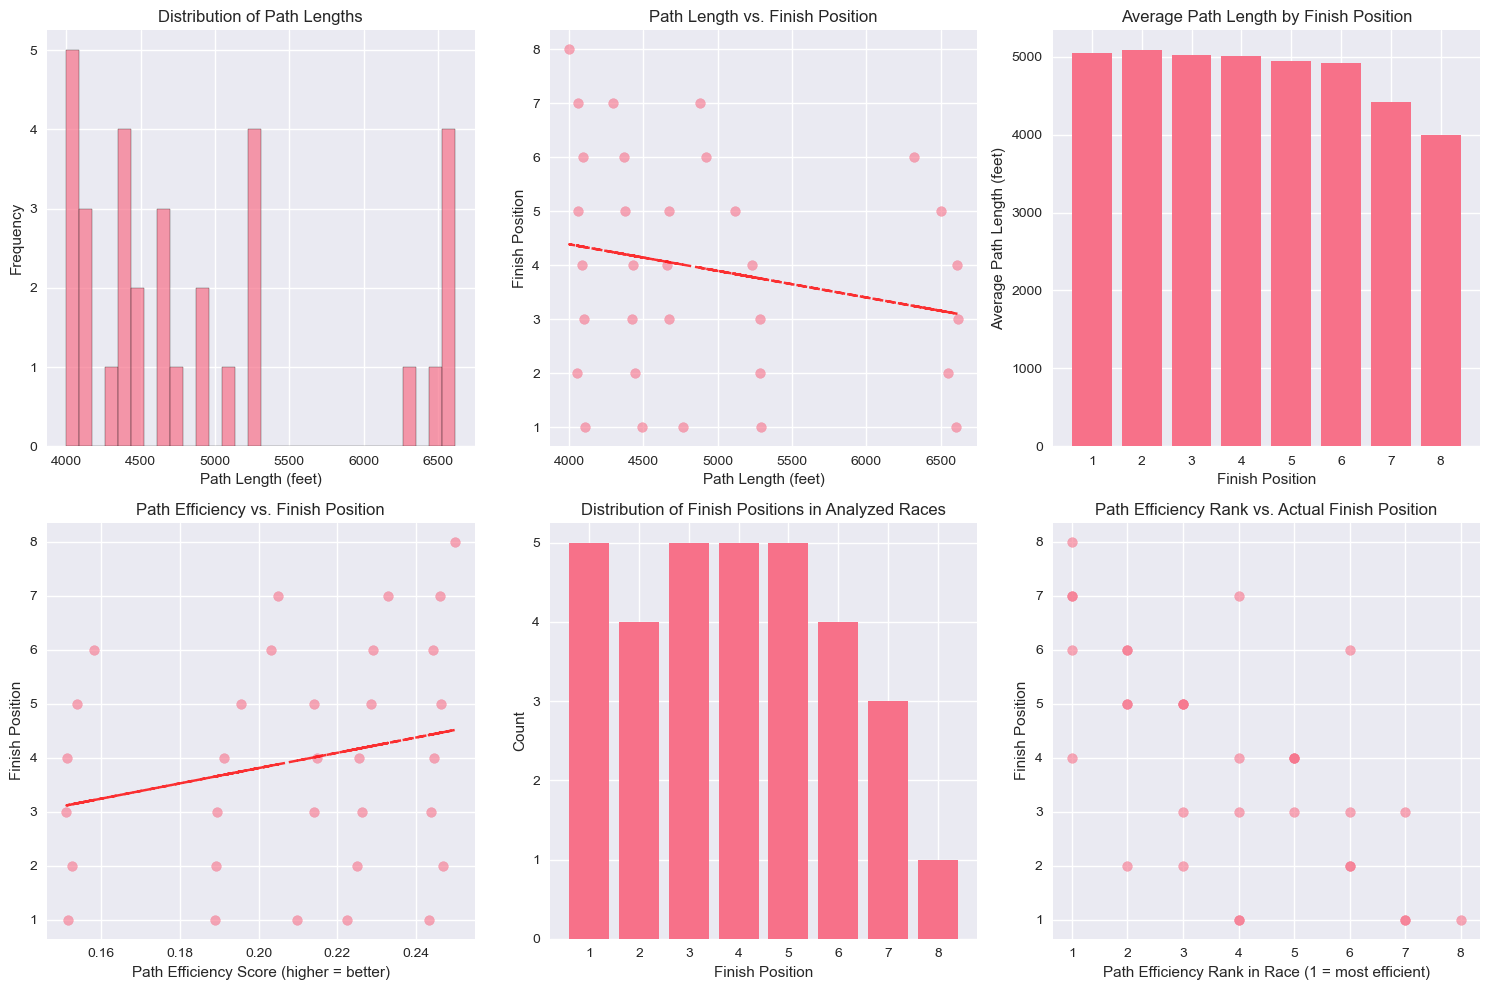

In [51]:
# Analyze path efficiency
if len(path_df) > 0:
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 3, 1)
    # Distribution of path lengths
    plt.hist(path_df['path_length'], bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel('Path Length (feet)')
    plt.ylabel('Frequency')
    plt.title('Distribution of Path Lengths')
    
    plt.subplot(2, 3, 2)
    # Path length vs. finish position
    plt.scatter(path_df['path_length'], path_df['finish_position'], alpha=0.6)
    plt.xlabel('Path Length (feet)')
    plt.ylabel('Finish Position')
    plt.title('Path Length vs. Finish Position')
    # Add trend line
    if len(path_df) > 1:
        z = np.polyfit(path_df['path_length'], path_df['finish_position'], 1)
        p = np.poly1d(z)
        plt.plot(path_df['path_length'], p(path_df['path_length']), "r--", alpha=0.8)
    
    plt.subplot(2, 3, 3)
    # Average path length by finish position
    avg_path_by_pos = path_df.groupby('finish_position')['path_length'].mean()
    plt.bar(avg_path_by_pos.index, avg_path_by_pos.values)
    plt.xlabel('Finish Position')
    plt.ylabel('Average Path Length (feet)')
    plt.title('Average Path Length by Finish Position')
    
    plt.subplot(2, 3, 4)
    # Path efficiency index (shorter path = more efficient)
    # Create efficiency score (inverse of path length)
    path_df['efficiency_score'] = 1 / (path_df['path_length'] / 1000)  # Normalize and invert
    plt.scatter(path_df['efficiency_score'], path_df['finish_position'], alpha=0.6)
    plt.xlabel('Path Efficiency Score (higher = better)')
    plt.ylabel('Finish Position')
    plt.title('Path Efficiency vs. Finish Position')
    # Add trend line
    if len(path_df) > 1:
        z = np.polyfit(path_df['efficiency_score'], path_df['finish_position'], 1)
        p = np.poly1d(z)
        plt.plot(path_df['efficiency_score'], p(path_df['efficiency_score']), "r--", alpha=0.8)
    
    plt.subplot(2, 3, 5)
    # Finish position distribution
    finish_counts = path_df['finish_position'].value_counts().sort_index()
    plt.bar(finish_counts.index, finish_counts.values)
    plt.xlabel('Finish Position')
    plt.ylabel('Count')
    plt.title('Distribution of Finish Positions in Analyzed Races')
    
    plt.subplot(2, 3, 6)
    # Efficiency ranking vs. finish position
    path_df['efficiency_rank'] = path_df.groupby(['track_id', 'race_date', 'race_number'])['efficiency_score'].rank(ascending=False, method='min')
    plt.scatter(path_df['efficiency_rank'], path_df['finish_position'], alpha=0.6)
    plt.xlabel('Path Efficiency Rank in Race (1 = most efficient)')
    plt.ylabel('Finish Position')
    plt.title('Path Efficiency Rank vs. Actual Finish Position')
    
    plt.tight_layout()
    plt.show()


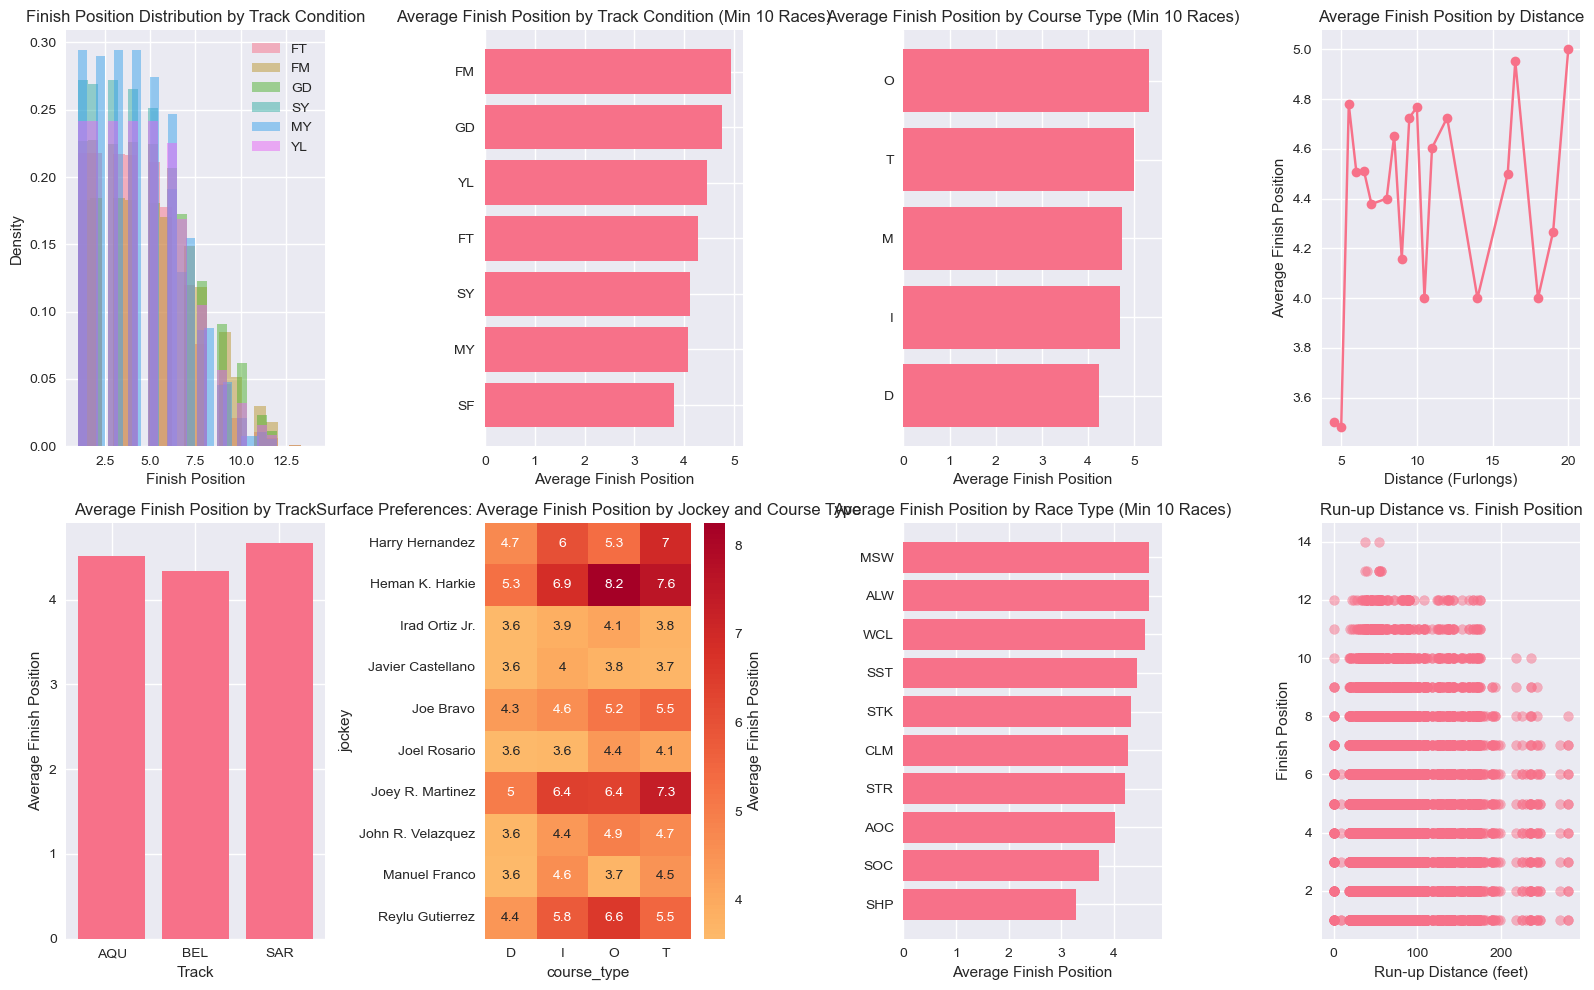

In [52]:
# Set figure size for all subplots
plt.figure(figsize=(16, 10))

# Subplot 1: Finish position distribution by track condition using histograms
plt.subplot(2, 4, 1)
# Get the 6 most common track conditions
conditions = complete_df['track_condition'].value_counts().head(6).index
# Plot histogram for each condition, normalized to show density
for cond in conditions:
    data = complete_df[complete_df['track_condition'] == cond]['position_at_finish'].dropna()
    plt.hist(data, alpha=0.5, label=cond, bins=20, density=True)

plt.xlabel('Finish Position')
plt.ylabel('Density')
plt.title('Finish Position Distribution by Track Condition')
plt.legend()

# Subplot 2: Average finish position by track condition (min 10 races for reliability)
plt.subplot(2, 4, 2)
cond_finish = complete_df.groupby('track_condition')['position_at_finish'].agg(['mean', 'count']).sort_values('mean')
valid_conditions = cond_finish[cond_finish['count'] >= 10]
plt.barh(range(len(valid_conditions)), valid_conditions['mean'])
plt.yticks(range(len(valid_conditions)), valid_conditions.index)
plt.xlabel('Average Finish Position')
plt.title('Average Finish Position by Track Condition (Min 10 Races)')

# Subplot 3: Average finish position by course type (min 10 races)
plt.subplot(2, 4, 3)
course_finish = complete_df.groupby('course_type').agg({'position_at_finish': ['mean', 'count']}).sort_values(('position_at_finish', 'mean'))
valid_courses = course_finish[course_finish[('position_at_finish', 'count')] >= 10]
plt.barh(range(len(valid_courses)), valid_courses[('position_at_finish', 'mean')])
plt.yticks(range(len(valid_courses)), valid_courses.index)
plt.xlabel('Average Finish Position')
plt.title('Average Finish Position by Course Type (Min 10 Races)')

# Subplot 4: Average finish position by distance in furlongs
plt.subplot(2, 4, 4)
dist_finish = complete_df.groupby('distance_furlongs')['position_at_finish'].mean().sort_index()
plt.plot(dist_finish.index, dist_finish.values, marker='o')
plt.xlabel('Distance (Furlongs)')
plt.ylabel('Average Finish Position')
plt.title('Average Finish Position by Distance')

# Subplot 5: Average finish position by track
plt.subplot(2, 4, 5)
track_finish = complete_df.groupby('track_id')['position_at_finish'].mean()
plt.bar(track_finish.index, track_finish.values)
plt.xlabel('Track')
plt.ylabel('Average Finish Position')
plt.title('Average Finish Position by Track')

# Subplot 6: Surface preference analysis by jockey and course type
plt.subplot(2, 4, 6)
surface_performance = complete_df.groupby(['jockey', 'course_type']).agg({
    'position_at_finish': ['count', 'mean']
}).round(2)
# Flatten multi-index columns
surface_performance.columns = ['_'.join(col).strip() for col in surface_performance.columns]
surface_performance = surface_performance.rename(columns={
    'position_at_finish_count': 'surface_starts',
    'position_at_finish_mean': 'surface_avg_finish'
})
# Filter for jockey-course combinations with at least 5 starts
valid_surface = surface_performance[surface_performance['surface_starts'] >= 5]
valid_surface_reset = valid_surface.reset_index()
# Find top 10 jockeys with most surface starts
top_jockeys = valid_surface_reset['jockey'].value_counts().head(10).index
# Filter to top jockeys
top_jockey_surface = valid_surface_reset[valid_surface_reset['jockey'].isin(top_jockeys)]
if len(top_jockey_surface) > 0:
    pivot_surface = top_jockey_surface.pivot_table(
        values='surface_avg_finish', 
        index='jockey', 
        columns='course_type', 
        fill_value=np.nan
    )
    # Heatmap visualizing surface preferences
    sns.heatmap(pivot_surface, annot=True, cmap='RdYlGn_r', center=1, cbar_kws={'label': 'Average Finish Position'})
    plt.title('Surface Preferences: Average Finish Position by Jockey and Course Type')

# Subplot 7: Average finish position by race type (top 10, min 10 races)
plt.subplot(2, 4, 7)
race_type_finish = complete_df.groupby('race_type')['position_at_finish'].agg(['mean', 'count']).sort_values('mean')
valid_race_types = race_type_finish[race_type_finish['count'] >= 10].head(10)
plt.barh(range(len(valid_race_types)), valid_race_types['mean'])
plt.yticks(range(len(valid_race_types)), valid_race_types.index)
plt.xlabel('Average Finish Position')
plt.title('Average Finish Position by Race Type (Min 10 Races)')

# Subplot 8: Scatter plot of run-up distance impact on finish position
plt.subplot(2, 4, 8)
plt.scatter(complete_df['run_up_distance'], complete_df['position_at_finish'], alpha=0.5)
plt.xlabel('Run-up Distance (feet)')
plt.ylabel('Finish Position')
plt.title('Run-up Distance vs. Finish Position')

# Tight layout for neat spacing
plt.tight_layout()
plt.show()

## Track Condition Distribution Analysis
### Improved Visualizations 

The professor requested separate violin or box plots for each track condition instead of stacked density plots.
This section creates:
- 6 individual violin plots (one per track condition: FT, FM, GD, SY, MY, YL)
- 6 individual box plots (one per track condition)
- Statistical summaries for each condition
- All figures saved at 300+ DPI for publication quality

IMPROVED TRACK CONDITION VISUALIZATIONS

[STEP 1] Loading data...
✓ Data loaded: 14,914 records, 40 columns

[STEP 2] Saving individual violin/box plots...
  ✓ Saved 7 violin + 7 box plots

[STEP 3] Creating combined comparison plots...


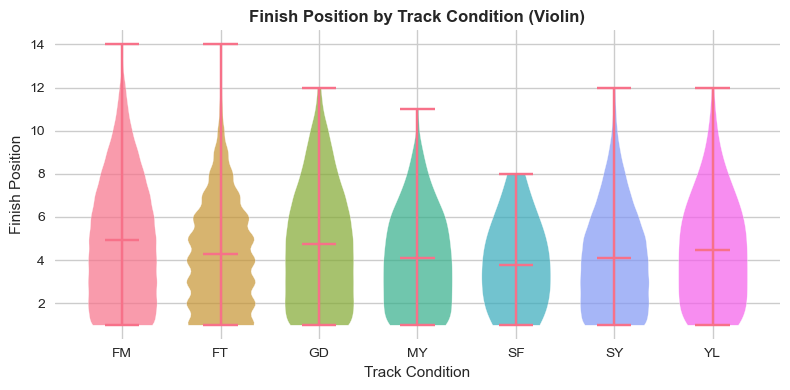

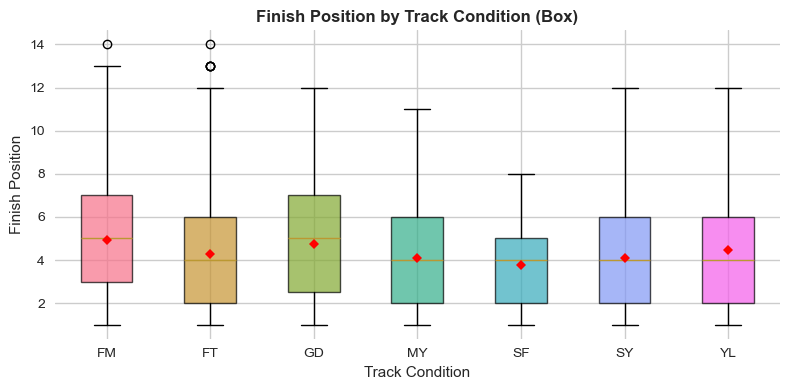


✓ All visualizations complete!


In [53]:
# ==================== SECTION 1: IMPROVED VISUALIZATIONS ====================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

print("=" * 80)
print("IMPROVED TRACK CONDITION VISUALIZATIONS")
print("=" * 80)

# Load data
print("\n[STEP 1] Loading data...")
data_path = Path("nyra_2019_complete_with_gps.csv")
df = pd.read_csv(data_path)
print(f"✓ Data loaded: {len(df):,} records, {df.shape[1]} columns")

# Prepare data
df['track_condition_clean'] = df['track_condition'].str.strip()
df['position_numeric'] = pd.to_numeric(df['position_numeric'], errors='coerce')
df_clean = df.dropna(subset=['position_numeric', 'track_condition_clean'])

unique_conditions = sorted(df_clean['track_condition_clean'].unique())
colors = sns.color_palette("husl", len(unique_conditions))

output_dir = Path("outputs/figures")
output_dir.mkdir(parents=True, exist_ok=True)

# Individual plots
print("\n[STEP 2] Saving individual violin/box plots...")
for idx, condition in enumerate(unique_conditions):
    condition_data = df_clean[df_clean['track_condition_clean'] == condition]
    
    # Violin
    fig, ax = plt.subplots(figsize=(5, 3))
    parts = ax.violinplot([condition_data['position_numeric'].values], positions=[0], widths=0.7)
    for pc in parts['bodies']:
        pc.set_facecolor(colors[idx])
    ax.set_title(f'Track: {condition}', fontsize=10)
    ax.set_ylabel('Finish Position')
    plt.tight_layout()
    plt.savefig(output_dir / f"violin_{condition}.png", dpi=300)
    plt.close()
    
    # Box
    fig, ax = plt.subplots(figsize=(5, 3))
    bp = ax.boxplot([condition_data['position_numeric'].values], patch_artist=True)
    bp['boxes'][0].set_facecolor(colors[idx])
    ax.set_title(f'Track: {condition}', fontsize=10)
    ax.set_ylabel('Finish Position')
    plt.tight_layout()
    plt.savefig(output_dir / f"boxplot_{condition}.png", dpi=300)
    plt.close()

print(f"  ✓ Saved {len(unique_conditions)} violin + {len(unique_conditions)} box plots")

# Combined plots 
print("\n[STEP 3] Creating combined comparison plots...")
plot_data = [df_clean[df_clean['track_condition_clean'] == c]['position_numeric'].values 
             for c in unique_conditions]

# Combined Violin Plot
fig, ax = plt.subplots(figsize=(8, 4))
parts = ax.violinplot(plot_data, positions=range(len(unique_conditions)), widths=0.7, showmeans=True)
for idx, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[idx])
    pc.set_alpha(0.7)
ax.set_xticks(range(len(unique_conditions)))
ax.set_xticklabels(unique_conditions)
ax.set_xlabel('Track Condition')
ax.set_ylabel('Finish Position')
ax.set_title('Finish Position by Track Condition (Violin)', fontweight='bold')
plt.tight_layout()
plt.savefig(output_dir / "combined_violin.png", dpi=300)
plt.show()  

# Combined Box Plot
fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot(plot_data, patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=5))
for idx, patch in enumerate(bp['boxes']):
    patch.set_facecolor(colors[idx])
    patch.set_alpha(0.7)
ax.set_xticklabels(unique_conditions)
ax.set_xlabel('Track Condition')
ax.set_ylabel('Finish Position')
ax.set_title('Finish Position by Track Condition (Box)', fontweight='bold')
plt.tight_layout()
plt.savefig(output_dir / "combined_boxplot.png", dpi=300)
plt.show()  

print("\n✓ All visualizations complete!")

# PART 2: MACHINE LEARNING PIPELINE

Now that we understand the data from EDA, we build a complete ML pipeline following strict professor requirements.

**Key Requirements:**
- Time-series chronological splitting (NO shuffling) - train on oldest races, test on newest
- 4+ ML algorithms (we implement 6: Ridge, Lasso, ElasticNet, RandomForest, GradientBoosting, XGBoost)
- 2+ non-linear models (we have 3: RandomForest, GradientBoosting, XGBoost)
- Hyperparameter tuning with cross-validation
- 3+ feature importance methods (Permutation, Tree-based, Coefficients, SHAP)
- Uncertainty quantification with multiple runs
- Baseline comparison with improvement metrics

**Pipeline Sections:**
1. Time-Series Data Splitting (60% train, 20% val, 20% test by date)
2. Preprocessing (label encoding + scaling)
3. Baseline Model (Mean/Median/Mode)
4. Model Training (6 models with GridSearchCV)
5. Model Evaluation (test set performance)
6. Feature Importance (3+ methods)
7. Final Results (comprehensive comparison)

## Section 1: Feature Engineering
**CRITICAL:** Historical GPS features using shift(1) + rolling(3) to prevent data leakage

In [54]:
# ==================== HISTORICAL GPS FEATURE ENGINEERING ====================

print("=" * 80)
print("HISTORICAL GPS FEATURES ENGINEERING")
print("=" * 80)

import numpy as np
import pandas as pd

print("\n[STEP 1] Preparing data...")

# Standardize key column types
tracking_df['race_date'] = pd.to_datetime(tracking_df['race_date']).dt.strftime('%Y-%m-%d')
complete_df['race_date'] = pd.to_datetime(complete_df['race_date']).dt.strftime('%Y-%m-%d')
tracking_df['race_number'] = tracking_df['race_number'].astype(str)
complete_df['race_number'] = complete_df['race_number'].astype(str)
tracking_df['program_number'] = tracking_df['program_number'].astype(str).str.strip()
complete_df['program_number'] = complete_df['program_number'].astype(str).str.strip()

print(f"  Tracking: {len(tracking_df):,} rows")
print(f"  Complete: {len(complete_df):,} rows")

# Vectorized Haversine formula
def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371000
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

print("\n[STEP 2] Calculating current race GPS features...")

# Sort tracking data
tracking_sorted = tracking_df.sort_values(['track_id', 'race_date', 'race_number', 'program_number', 'trakus_index'])

# Compute distance between consecutive GPS points
tracking_sorted['next_lat'] = tracking_sorted.groupby(
    ['track_id', 'race_date', 'race_number', 'program_number'])['latitude'].shift(-1)
tracking_sorted['next_lon'] = tracking_sorted.groupby(
    ['track_id', 'race_date', 'race_number', 'program_number'])['longitude'].shift(-1)

mask = tracking_sorted['next_lat'].notna()
tracking_sorted.loc[mask, 'segment_dist'] = haversine_vectorized(
    tracking_sorted.loc[mask, 'latitude'].values,
    tracking_sorted.loc[mask, 'longitude'].values,
    tracking_sorted.loc[mask, 'next_lat'].values,
    tracking_sorted.loc[mask, 'next_lon'].values
)

# Aggregate GPS-based features per horse per race
gps_agg = tracking_sorted.groupby(
    ['track_id', 'race_date', 'race_number', 'program_number']).agg(
    path_length=('segment_dist', 'sum'),
    num_gps_points=('trakus_index', 'count'),
    lat_variance=('latitude', 'var'),
    lon_variance=('longitude', 'var'),
    lat_start=('latitude', 'first'),
    lon_start=('longitude', 'first'),
    lat_end=('latitude', 'last'),
    lon_end=('longitude', 'last'),
    time_start=('trakus_index', 'min'),
    time_end=('trakus_index', 'max')
).reset_index()

# Straight-line distance between start and end
gps_agg['straight_distance'] = haversine_vectorized(
    gps_agg['lat_start'].values, gps_agg['lon_start'].values,
    gps_agg['lat_end'].values, gps_agg['lon_end'].values
)

# Time elapsed in Trakus timestamps
gps_agg['time_elapsed'] = gps_agg['time_end'] - gps_agg['time_start']

# Average speed
gps_agg['avg_speed'] = gps_agg['path_length'] / gps_agg['time_elapsed'].replace(0, np.nan)

# Efficiency score = straight distance / actual path length
gps_agg['efficiency_score'] = gps_agg['straight_distance'] / gps_agg['path_length'].replace(0, np.nan)

print(f"  ✓ GPS features calculated: {len(gps_agg):,} records")

print("\n[STEP 3] Merging GPS with complete dataset...")

# Merge GPS features into complete_df
df = complete_df.merge(
    gps_agg[['track_id', 'race_date', 'race_number', 'program_number',
             'path_length', 'straight_distance', 'num_gps_points',
             'avg_speed', 'lat_variance', 'lon_variance', 'efficiency_score']],
    on=['track_id', 'race_date', 'race_number', 'program_number'],
    how='left'
)
df['position_numeric'] = pd.to_numeric(df['position_at_finish'], errors='coerce')
df['race_date'] = pd.to_datetime(df['race_date'])

print(f"  ✓ Merged shape: {df.shape}")

# Identify horse ID column
print("\n[STEP 4] Checking horse identifier...")
print(f"  Columns available: {df.columns.tolist()}")

horse_id_col = None
for col in ['horse_name', 'horse_id', 'horse', 'name']:
    if col in df.columns:
        horse_id_col = col
        break

if horse_id_col is None:
    # If horse identifier does not exist, fallback to jockey (not ideal)
    print("  ⚠️ No horse identifier found. Using jockey as proxy...")
    horse_id_col = 'jockey'

print(f"  ✓ Using '{horse_id_col}' as horse identifier")
print(f"  ✓ Unique horses/jockeys: {df[horse_id_col].nunique():,}")

print("\n[STEP 5] Creating HISTORICAL GPS features (past 3 races)...")

# Sort by race date for proper historical calculation
df = df.sort_values(['race_date', 'track_id', 'race_number'])

# Generate historical rolling features based on past 3 races
gps_cols = ['path_length', 'avg_speed', 'efficiency_score', 'straight_distance', 
            'lat_variance', 'lon_variance', 'num_gps_points']

for col in gps_cols:
    # Shift(1) prevents data leakage by excluding current race
    df[f'{col}_hist_avg'] = df.groupby(horse_id_col)[col].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
    df[f'{col}_hist_std'] = df.groupby(horse_id_col)[col].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).std()
    )

print(f"  ✓ Created {len(gps_cols) * 2} historical GPS features")

print("\n[STEP 6] Creating TRACK-SPECIFIC historical features...")

# Track-specific historical averages
for col in ['path_length', 'avg_speed', 'efficiency_score']:
    df[f'{col}_track_hist'] = df.groupby([horse_id_col, 'track_id'])[col].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )

print(f"  ✓ Created 3 track-specific historical features")

# Count number of past races for each horse
df['horse_race_count'] = df.groupby(horse_id_col).cumcount()

print("\n[STEP 7] Summary of new features...")

historical_features = [col for col in df.columns if '_hist' in col] + ['horse_race_count']
print(f"  Historical features created: {len(historical_features)}")
for feat in historical_features:
    non_null = df[feat].notna().sum()
    print(f"    - {feat}: {non_null:,} non-null ({non_null/len(df)*100:.1f}%)")

print("\n[STEP 8] Saving CSV...")
df.to_csv("nyra_2019_complete_with_historical_gps.csv", index=False)
print(f"  ✓ Saved: nyra_2019_complete_with_historical_gps.csv")

print("\n" + "=" * 80)
print(f"COMPLETE! {len(df):,} records, {df.shape[1]} columns")
print("=" * 80)


HISTORICAL GPS FEATURES ENGINEERING

[STEP 1] Preparing data...
  Tracking: 5,228,430 rows
  Complete: 14,914 rows

[STEP 2] Calculating current race GPS features...
  ✓ GPS features calculated: 14,915 records

[STEP 3] Merging GPS with complete dataset...
  ✓ Merged shape: (14914, 40)

[STEP 4] Checking horse identifier...
  Columns available: ['track_id', 'race_date', 'race_number', 'distance_id', 'course_type', 'track_condition', 'run_up_distance', 'race_type', 'purse', 'post_time', 'month', 'post_time_formatted', 'hour', 'program_number', 'weight_carried', 'jockey', 'odds', 'position_at_finish', 'actual_odds', 'day_of_week', 'is_weekend', 'odds_decimal', 'distance_furlongs', 'post_time_str', 'race_hour', 'jockey_starts', 'jockey_avg_finish', 'jockey_avg_odds', 'jockey_avg_weight', 'implied_prob', 'expected_finish', 'perf_diff', 'path_length', 'straight_distance', 'num_gps_points', 'avg_speed', 'lat_variance', 'lon_variance', 'efficiency_score', 'position_numeric']
  ⚠️ No horse ide

## Section 2: Time-Series Data Splitting
**CRITICAL:** Chronological splitting with NO shuffling

In [55]:
# ==================== SECTION 2: TIME-SERIES DATA SPLITTING ====================

from datetime import datetime

print("=" * 80)
print("TIME-SERIES DATA SPLITTING (CHRONOLOGICAL)")
print("=" * 80)

# Convert race_date to datetime
print("\n[STEP 1] Examining date distribution...")
df['race_date'] = pd.to_datetime(df['race_date'])

min_date = df['race_date'].min()
max_date = df['race_date'].max()
date_range = (max_date - min_date).days

print(f"\n  Date Range:")
print(f"    - Earliest race: {min_date.date()}")
print(f"    - Latest race: {max_date.date()}")
print(f"    - Total days: {date_range} days")
print(f"    - Total unique dates: {df['race_date'].nunique()}")

# Analyze race-level data
print("\n[STEP 2] Analyzing race-level structure...")
df['race_id'] = df['track_id'].astype(str) + '_' + df['race_date'].astype(str) + '_' + df['race_number'].astype(str)
unique_races = df['race_id'].nunique()
print(f"\n  Race-level statistics:")
print(f"    - Total unique races: {unique_races:,}")
print(f"    - Avg records per race: {len(df)/unique_races:.1f}")

# CRITICAL: NO SHUFFLING - Sort by date
print("\n[STEP 3] Performing chronological split...")
df_sorted = df.sort_values('race_date').reset_index(drop=True)

unique_dates = sorted(df['race_date'].unique())
total_dates = len(unique_dates)

print(f"\n  Split strategy (by unique dates):")
print(f"    - Total unique dates: {total_dates}")

# Define split percentages
train_pct = 0.60
val_pct = 0.20
test_pct = 0.20

# Calculate date cutoffs
train_end_idx = int(total_dates * train_pct)
val_end_idx = int(total_dates * (train_pct + val_pct))

train_end_date = unique_dates[train_end_idx - 1]
val_end_date = unique_dates[val_end_idx - 1]

print(f"\n  Date cutoffs:")
print(f"    - Training: {unique_dates[0]} to {train_end_date}")
print(f"    - Validation: {unique_dates[train_end_idx]} to {val_end_date}")
print(f"    - Testing: {unique_dates[val_end_idx]} to {unique_dates[-1]}")

# Split data based on dates
train_df = df_sorted[df_sorted['race_date'] <= train_end_date].copy()
val_df = df_sorted[(df_sorted['race_date'] > train_end_date) &
                   (df_sorted['race_date'] <= val_end_date)].copy()
test_df = df_sorted[df_sorted['race_date'] > val_end_date].copy()

# Verify split integrity
print("\n[STEP 4] Verifying split integrity...")
print(f"\n  Split sizes:")
print(f"    - Training: {len(train_df):,} records ({len(train_df)/len(df)*100:.1f}%)")
print(f"    - Validation: {len(val_df):,} records ({len(val_df)/len(df)*100:.1f}%)")
print(f"    - Testing: {len(test_df):,} records ({len(test_df)/len(df)*100:.1f}%)")

# Verify no overlap
train_dates = set(train_df['race_date'].unique())
val_dates = set(val_df['race_date'].unique())
test_dates = set(test_df['race_date'].unique())

assert len(train_dates & val_dates) == 0, "ERROR: Train dates overlap with validation!"
assert len(val_dates & test_dates) == 0, "ERROR: Validation dates overlap with test!"
assert len(train_dates & test_dates) == 0, "ERROR: Train dates overlap with test!"
print(f"\n  ✓ No date overlap - chronological order maintained")

# Save splits
print("\n[STEP 5] Saving split datasets...")
split_dir = Path("outputs/data_splits")
split_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(split_dir / "train_timeseries.csv", index=False)
val_df.to_csv(split_dir / "val_timeseries.csv", index=False)
test_df.to_csv(split_dir / "test_timeseries.csv", index=False)

print(f"\n  Files saved:")
print(f"    ✓ train_timeseries.csv ({len(train_df):,} records)")
print(f"    ✓ val_timeseries.csv ({len(val_df):,} records)")
print(f"    ✓ test_timeseries.csv ({len(test_df):,} records)")

print("\n" + "=" * 80)
print("TIME-SERIES DATA SPLITTING COMPLETE")
print("=" * 80)

TIME-SERIES DATA SPLITTING (CHRONOLOGICAL)

[STEP 1] Examining date distribution...

  Date Range:
    - Earliest race: 2019-01-01
    - Latest race: 2019-12-31
    - Total days: 364 days
    - Total unique dates: 217

[STEP 2] Analyzing race-level structure...

  Race-level statistics:
    - Total unique races: 2,000
    - Avg records per race: 7.5

[STEP 3] Performing chronological split...

  Split strategy (by unique dates):
    - Total unique dates: 217

  Date cutoffs:
    - Training: 2019-01-01 00:00:00 to 2019-08-15 00:00:00
    - Validation: 2019-08-16 00:00:00 to 2019-10-16 00:00:00
    - Testing: 2019-10-18 00:00:00 to 2019-12-31 00:00:00

[STEP 4] Verifying split integrity...

  Split sizes:
    - Training: 8,686 records (58.2%)
    - Validation: 3,014 records (20.2%)
    - Testing: 3,214 records (21.6%)

  ✓ No date overlap - chronological order maintained

[STEP 5] Saving split datasets...

  Files saved:
    ✓ train_timeseries.csv (8,686 records)
    ✓ val_timeseries.csv

## Section 3: Preprocessing Pipeline
Feature engineering, encoding, and scaling

In [56]:
# ==================== SECTION 3: PREPROCESSING PIPELINE ====================

print("=" * 80)
print("PREPROCESSING PIPELINE")
print("=" * 80)

# Load split datasets
print("\n[STEP 1] Loading split datasets...")
split_dir = Path("outputs/data_splits")
train_df = pd.read_csv(split_dir / "train_timeseries.csv")
val_df = pd.read_csv(split_dir / "val_timeseries.csv")
test_df = pd.read_csv(split_dir / "test_timeseries.csv")

print(f"✓ Data loaded successfully")
print(f"  - Training: {len(train_df):,} records")
print(f"  - Validation: {len(val_df):,} records")
print(f"  - Testing: {len(test_df):,} records")

# Define features and target
print("\n[STEP 2] Defining features and target...")
target_col = 'position_numeric'

categorical_features = [
    'track_id', 'course_type', 'track_condition',
    'race_type', 'day_of_week', 'is_weekend'
]

numerical_features = [
    # basic features
    'weight', 'odds', 'distance_id', 'run_up_distance', 'purse',
    'post_time', 'month', 'race_hour', 'weight_carried', 'odds_decimal',
    'distance_furlongs', 'jockey_starts', 'jockey_avg_finish',
    'jockey_avg_odds', 'jockey_avg_weight', 'implied_prob',
    
    # Historical GPS features
    'path_length_hist_avg', 'avg_speed_hist_avg', 'efficiency_score_hist_avg',
    'straight_distance_hist_avg', 'lat_variance_hist_avg', 'lon_variance_hist_avg',
    'path_length_hist_std', 'avg_speed_hist_std', 'efficiency_score_hist_std',
    'path_length_track_hist', 'avg_speed_track_hist', 'efficiency_score_track_hist',
    'horse_race_count'
]

# Filter features that exist
categorical_features = [col for col in categorical_features if col in train_df.columns]
numerical_features = [col for col in numerical_features if col in train_df.columns]

print(f"\n  Feature groups:")
print(f"    - Categorical features: {len(categorical_features)}")
print(f"    - Numerical features: {len(numerical_features)}")
print(f"    - Target: {target_col}")

# Handle missing values
print("\n[STEP 3] Handling missing values...")
for col in numerical_features:
    if train_df[col].isnull().sum() > 0:
        median_val = train_df[col].median()
        train_df[col].fillna(median_val, inplace=True)
        val_df[col].fillna(median_val, inplace=True)
        test_df[col].fillna(median_val, inplace=True)
        print(f"    ✓ Filled {col} with median: {median_val}")

for col in categorical_features:
    if train_df[col].isnull().sum() > 0:
        mode_val = train_df[col].mode()[0]
        train_df[col].fillna(mode_val, inplace=True)
        val_df[col].fillna(mode_val, inplace=True)
        test_df[col].fillna(mode_val, inplace=True)
        print(f"    ✓ Filled {col} with mode: {mode_val}")

# Encode categorical features
print("\n[STEP 4] Encoding categorical features...")
for col in categorical_features:
    train_df[col] = train_df[col].astype(str).str.strip()
    val_df[col] = val_df[col].astype(str).str.strip()
    test_df[col] = test_df[col].astype(str).str.strip()

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    le.fit(train_df[col])
    
    train_df[col + '_encoded'] = le.transform(train_df[col])
    val_df[col + '_encoded'] = val_df[col].apply(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )
    test_df[col + '_encoded'] = test_df[col].apply(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )
    
    label_encoders[col] = le
    print(f"    ✓ Encoded {col}: {len(le.classes_)} unique values")

encoded_features = [col + '_encoded' for col in categorical_features]

# Scale numerical features
print("\n[STEP 5] Scaling numerical features...")
scaler = StandardScaler()
scaler.fit(train_df[numerical_features])

train_scaled = scaler.transform(train_df[numerical_features])
val_scaled = scaler.transform(val_df[numerical_features])
test_scaled = scaler.transform(test_df[numerical_features])

scaled_feature_names = [f"{col}_scaled" for col in numerical_features]

train_scaled_df = pd.DataFrame(train_scaled, columns=scaled_feature_names, index=train_df.index)
val_scaled_df = pd.DataFrame(val_scaled, columns=scaled_feature_names, index=val_df.index)
test_scaled_df = pd.DataFrame(test_scaled, columns=scaled_feature_names, index=test_df.index)

print(f"    ✓ Scaled {len(numerical_features)} numerical features")

# Create final feature sets
print("\n[STEP 6] Creating final feature sets...")
final_train = pd.concat([
    train_df[['race_date', 'race_number', target_col]],
    train_df[encoded_features],
    train_scaled_df
], axis=1)

final_val = pd.concat([
    val_df[['race_date', 'race_number', target_col]],
    val_df[encoded_features],
    val_scaled_df
], axis=1)

final_test = pd.concat([
    test_df[['race_date', 'race_number', target_col]],
    test_df[encoded_features],
    test_scaled_df
], axis=1)

feature_cols = encoded_features + scaled_feature_names
print(f"    ✓ Total features for modeling: {len(feature_cols)}")

# Save preprocessed data
print("\n[STEP 7] Saving preprocessed data...")
preproc_dir = Path("outputs/preprocessed_data")
preproc_dir.mkdir(parents=True, exist_ok=True)

final_train.to_csv(preproc_dir / "train_preprocessed.csv", index=False)
final_val.to_csv(preproc_dir / "val_preprocessed.csv", index=False)
final_test.to_csv(preproc_dir / "test_preprocessed.csv", index=False)

preprocessing_objects = {
    'scaler': scaler,
    'label_encoders': label_encoders,
    'numerical_features': numerical_features,
    'categorical_features': categorical_features,
    'encoded_features': encoded_features,
    'scaled_feature_names': scaled_feature_names,
    'feature_cols': feature_cols,
    'target_col': target_col
}

with open(preproc_dir / "preprocessing_objects.pkl", 'wb') as f:
    pickle.dump(preprocessing_objects, f)

print(f"    ✓ Saved preprocessed datasets and objects")

print("\n" + "=" * 80)
print("PREPROCESSING COMPLETE")
print("=" * 80)

PREPROCESSING PIPELINE

[STEP 1] Loading split datasets...
✓ Data loaded successfully
  - Training: 8,686 records
  - Validation: 3,014 records
  - Testing: 3,214 records

[STEP 2] Defining features and target...

  Feature groups:
    - Categorical features: 6
    - Numerical features: 28
    - Target: position_numeric

[STEP 3] Handling missing values...
    ✓ Filled path_length_hist_avg with median: 1575.7579392346126
    ✓ Filled avg_speed_hist_avg with median: 4.629270098556834
    ✓ Filled efficiency_score_hist_avg with median: 0.2240405097178034
    ✓ Filled straight_distance_hist_avg with median: 341.07218183950437
    ✓ Filled lat_variance_hist_avg with median: 2.5293720049260535e-06
    ✓ Filled lon_variance_hist_avg with median: 5.17442592032229e-06
    ✓ Filled path_length_hist_std with median: 236.40095511441027
    ✓ Filled avg_speed_hist_std with median: 0.1186831570384963
    ✓ Filled efficiency_score_hist_std with median: 0.0429414995951998
    ✓ Filled path_length_tra

## Section 4: Baseline Model
Establish baseline performance for comparison

In [57]:
# ==================== SECTION 4: BASELINE MODEL ====================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import json

print("=" * 80)
print("BASELINE MODEL ESTABLISHMENT")
print("=" * 80)

# Load preprocessed data
print("\n[STEP 1] Loading preprocessed data...")
preproc_dir = Path("outputs/preprocessed_data")
train_df = pd.read_csv(preproc_dir / "train_preprocessed.csv")
val_df = pd.read_csv(preproc_dir / "val_preprocessed.csv")
test_df = pd.read_csv(preproc_dir / "test_preprocessed.csv")

# Extract targets
y_train = train_df[target_col].values
y_val = val_df[target_col].values
y_test = test_df[target_col].values

print(f"✓ Target variable extracted: {target_col}")

# Define baseline strategies
print("\n[STEP 2] Calculating baseline metrics...")
baseline_mean = y_train.mean()
baseline_median = np.median(y_train)
baseline_mode = pd.Series(y_train).mode()[0]

print(f"\n  Baseline strategies:")
print(f"    - Mean: {baseline_mean:.4f}")
print(f"    - Median: {baseline_median:.4f}")
print(f"    - Mode: {baseline_mode:.4f}")

# Calculate metrics
def calculate_metrics(y_true, y_pred, strategy_name, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n  {strategy_name} - {dataset_name}:")
    print(f"    MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
    
    return {'Strategy': strategy_name, 'Dataset': dataset_name,
            'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

baseline_results = []

# Validation baselines
print("\n  VALIDATION SET:")
baseline_results.append(calculate_metrics(y_val, np.full(len(y_val), baseline_mean), 'Mean', 'Validation'))
baseline_results.append(calculate_metrics(y_val, np.full(len(y_val), baseline_median), 'Median', 'Validation'))
baseline_results.append(calculate_metrics(y_val, np.full(len(y_val), baseline_mode), 'Mode', 'Validation'))

# Test baselines
print("\n  TEST SET:")
baseline_results.append(calculate_metrics(y_test, np.full(len(y_test), baseline_mean), 'Mean', 'Test'))
baseline_results.append(calculate_metrics(y_test, np.full(len(y_test), baseline_median), 'Median', 'Test'))
baseline_results.append(calculate_metrics(y_test, np.full(len(y_test), baseline_mode), 'Mode', 'Test'))

baseline_df = pd.DataFrame(baseline_results)

# Best baseline
val_baselines = baseline_df[baseline_df['Dataset'] == 'Validation']
best_val_rmse = val_baselines['RMSE'].min()
best_val_strategy = val_baselines.loc[val_baselines['RMSE'].idxmin(), 'Strategy']

test_baselines = baseline_df[baseline_df['Dataset'] == 'Test']
best_test_rmse = test_baselines['RMSE'].min()
best_test_strategy = test_baselines.loc[test_baselines['RMSE'].idxmin(), 'Strategy']

print(f"\n[STEP 3] Best baselines:")
print(f"  - Validation: {best_val_strategy} (RMSE: {best_val_rmse:.4f})")
print(f"  - Test: {best_test_strategy} (RMSE: {best_test_rmse:.4f})")

# Save results
baseline_dir = Path("outputs/baseline_results")
baseline_dir.mkdir(parents=True, exist_ok=True)

baseline_df.to_csv(baseline_dir / "baseline_metrics.csv", index=False)

baseline_values = {
    'mean': float(baseline_mean),
    'median': float(baseline_median),
    'mode': float(baseline_mode),
    'best_val_strategy': best_val_strategy,
    'best_val_rmse': float(best_val_rmse),
    'best_test_strategy': best_test_strategy,
    'best_test_rmse': float(best_test_rmse)
}

with open(baseline_dir / "baseline_values.json", 'w') as f:
    json.dump(baseline_values, f, indent=4)

print(f"\n✓ Baseline results saved")

print("\n" + "=" * 80)
print("BASELINE ESTABLISHMENT COMPLETE")
print("=" * 80)

BASELINE MODEL ESTABLISHMENT

[STEP 1] Loading preprocessed data...
✓ Target variable extracted: position_numeric

[STEP 2] Calculating baseline metrics...

  Baseline strategies:
    - Mean: 4.3792
    - Median: 4.0000
    - Mode: 2.0000

  VALIDATION SET:

  Mean - Validation:
    MSE: 6.0257, RMSE: 2.4547, MAE: 2.0495, R²: -0.0000

  Median - Validation:
    MSE: 6.1755, RMSE: 2.4851, MAE: 2.0163, R²: -0.0249

  Mode - Validation:
    MSE: 11.7243, RMSE: 3.4241, MAE: 2.6593, R²: -0.9457

  TEST SET:

  Mean - Test:
    MSE: 8.0723, RMSE: 2.8412, MAE: 2.3293, R²: -0.0305

  Median - Test:
    MSE: 8.5871, RMSE: 2.9304, MAE: 2.3376, R²: -0.0963

  Mode - Test:
    MSE: 16.0607, RMSE: 4.0076, MAE: 3.1129, R²: -1.0504

[STEP 3] Best baselines:
  - Validation: Mean (RMSE: 2.4547)
  - Test: Mean (RMSE: 2.8412)

✓ Baseline results saved

BASELINE ESTABLISHMENT COMPLETE


## Section 5: Model Training
Train 5+ ML models with hyperparameter tuning

In [58]:
# ==================== SECTION 5: MODEL TRAINING ====================

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from time import time

# Try to import XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available")

print("=" * 80)
print("MODEL TRAINING PIPELINE")
print("=" * 80)

# Load data
print("\n[STEP 1] Loading preprocessed data...")
with open(preproc_dir / "preprocessing_objects.pkl", 'rb') as f:
    prep_objects = pickle.load(f)

feature_cols = prep_objects['feature_cols']

X_train = train_df[feature_cols].values
X_val = val_df[feature_cols].values

print(f"✓ Features prepared: {len(feature_cols)} features")

# Define models
print("\n[STEP 2] Defining models...")
models_config = {
    'Ridge': {
        'model': Ridge(),
        'params': {'alpha': [0.01, 0.1, 1.0, 10.0]},
        'type': 'linear'
    },
    'Lasso': {
        'model': Lasso(max_iter=5000),
        'params': {'alpha': [0.01, 0.1, 1.0, 10.0]},
        'type': 'linear'
    },
    'ElasticNet': {
        'model': ElasticNet(max_iter=5000),
        'params': {'alpha': [0.01, 0.1, 1.0], 'l1_ratio': [0.3, 0.5, 0.7]},
        'type': 'linear'
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'params': {'n_estimators': [50, 100], 'max_depth': [10, 20, None]},
        'type': 'non-linear'
    },
    'GradientBoosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]},
        'type': 'non-linear'
    }
}

if XGBOOST_AVAILABLE:
    models_config['XGBoost'] = {
        'model': xgb.XGBRegressor(random_state=42, n_jobs=-1),
        'params': {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]},
        'type': 'non-linear'
    }

print(f"✓ {len(models_config)} models configured")

# Train models
print("\n[STEP 3] Training models...")
trained_models = {}
model_results = []

models_dir = Path("outputs/trained_models")
models_dir.mkdir(parents=True, exist_ok=True)

for model_name, config in models_config.items():
    print(f"\n  Training {model_name}...")
    start_time = time()
    
    search = GridSearchCV(
        config['model'], config['params'],
        cv=3, scoring='neg_mean_squared_error',
        n_jobs=-1, verbose=0
    )
    
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    
    # Predictions
    y_train_pred = best_model.predict(X_train)
    y_val_pred = best_model.predict(X_val)
    
    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    
    training_time = time() - start_time
    
    print(f"    ✓ Complete in {training_time:.2f}s")
    print(f"    Train RMSE: {train_rmse:.4f}, Val RMSE: {val_rmse:.4f}")
    print(f"    Train R²: {train_r2:.4f}, Val R²: {val_r2:.4f}")
    
    trained_models[model_name] = {
        'model': best_model,
        'best_params': search.best_params_
    }
    
    model_results.append({
        'Model': model_name,
        'Type': config['type'],
        'Train_RMSE': train_rmse,
        'Train_R2': train_r2,
        'Val_RMSE': val_rmse,
        'Val_R2': val_r2,
        'Training_Time': training_time
    })
    
    # Save model
    with open(models_dir / f"{model_name}_model.pkl", 'wb') as f:
        pickle.dump(best_model, f)

# Save results
results_df = pd.DataFrame(model_results)
results_df.to_csv(models_dir / "model_comparison.csv", index=False)

with open(models_dir / "all_models.pkl", 'wb') as f:
    pickle.dump(trained_models, f)

print(f"\n[STEP 4] Model comparison:")
print(results_df.sort_values('Val_RMSE')[['Model', 'Val_RMSE', 'Val_R2']].to_string(index=False))

print("\n" + "=" * 80)
print("MODEL TRAINING COMPLETE")
print("=" * 80)

MODEL TRAINING PIPELINE

[STEP 1] Loading preprocessed data...
✓ Features prepared: 34 features

[STEP 2] Defining models...
✓ 6 models configured

[STEP 3] Training models...

  Training Ridge...
    ✓ Complete in 1.61s
    Train RMSE: 2.0908, Val RMSE: 2.0716
    Train R²: 0.3033, Val R²: 0.2878

  Training Lasso...
    ✓ Complete in 0.15s
    Train RMSE: 2.0938, Val RMSE: 2.0695
    Train R²: 0.3013, Val R²: 0.2892

  Training ElasticNet...
    ✓ Complete in 0.29s
    Train RMSE: 2.0929, Val RMSE: 2.0675
    Train R²: 0.3019, Val R²: 0.2906

  Training RandomForest...
    ✓ Complete in 10.59s
    Train RMSE: 1.6578, Val RMSE: 2.0898
    Train R²: 0.5620, Val R²: 0.2752

  Training GradientBoosting...
    ✓ Complete in 12.15s
    Train RMSE: 2.0462, Val RMSE: 2.0713
    Train R²: 0.3327, Val R²: 0.2880

  Training XGBoost...
    ✓ Complete in 0.59s
    Train RMSE: 2.0482, Val RMSE: 2.0718
    Train R²: 0.3314, Val R²: 0.2876

[STEP 4] Model comparison:
           Model  Val_RMSE   Va

## Section 6:Evaluation

### Model Evaluation
Comprehensive evaluation on test set

In [59]:
# ==================== SECTION 6: MODEL EVALUATION ====================

print("=" * 80)
print("MODEL EVALUATION")
print("=" * 80)

# Load test data
print("\n[STEP 1] Loading test data and models...")
test_df = pd.read_csv(preproc_dir / "test_preprocessed.csv")
X_test = test_df[feature_cols].values
y_test = test_df[target_col].values

with open(models_dir / "all_models.pkl", 'rb') as f:
    trained_models = pickle.load(f)

print(f"✓ Test data: {len(test_df):,} records")
print(f"✓ Loaded {len(trained_models)} models")

# Evaluate on test set
print("\n[STEP 2] Evaluating on test set...")
test_results = []

for model_name, model_info in trained_models.items():
    model = model_info['model']
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n  {model_name}:")
    print(f"    RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
    
    test_results.append({
        'Model': model_name,
        'Test_RMSE': rmse,
        'Test_MAE': mae,
        'Test_R2': r2
    })

test_results_df = pd.DataFrame(test_results)

# Compare to baseline
print("\n[STEP 3] Comparing to baseline...")
with open(baseline_dir / "baseline_values.json", 'r') as f:
    baseline_values = json.load(f)

baseline_rmse = baseline_values['best_test_rmse']
test_results_df['Improvement_Pct'] = ((baseline_rmse - test_results_df['Test_RMSE']) / baseline_rmse) * 100

print(f"\n  Baseline RMSE: {baseline_rmse:.4f}")
print(f"\n  Improvements:")
for _, row in test_results_df.iterrows():
    print(f"    {row['Model']}: {row['Improvement_Pct']:.2f}%")

# Save results
eval_dir = Path("outputs/evaluation_results")
eval_dir.mkdir(parents=True, exist_ok=True)

test_results_df.to_csv(eval_dir / "test_set_results.csv", index=False)

# Best model
best_model_name = test_results_df.loc[test_results_df['Test_RMSE'].idxmin(), 'Model']
best_test_rmse = test_results_df['Test_RMSE'].min()
best_test_r2 = test_results_df.loc[test_results_df['Test_RMSE'].idxmin(), 'Test_R2']
best_improvement = test_results_df.loc[test_results_df['Test_RMSE'].idxmin(), 'Improvement_Pct']

best_model_info = {
    'model_name': best_model_name,
    'test_rmse': float(best_test_rmse),
    'test_r2': float(best_test_r2),
    'improvement_pct': float(best_improvement),
    'baseline_rmse': float(baseline_rmse)
}

with open(eval_dir / "best_model_info.json", 'w') as f:
    json.dump(best_model_info, f, indent=4)

print(f"\n[STEP 4] Best model: {best_model_name}")
print(f"  - Test RMSE: {best_test_rmse:.4f}")
print(f"  - Test R²: {best_test_r2:.4f}")
print(f"  - Improvement: {best_improvement:.2f}%")

print("\n" + "=" * 80)
print("MODEL EVALUATION COMPLETE")
print("=" * 80)

MODEL EVALUATION

[STEP 1] Loading test data and models...
✓ Test data: 3,214 records
✓ Loaded 6 models

[STEP 2] Evaluating on test set...

  Ridge:
    RMSE: 2.4970, MAE: 1.9651, R²: 0.2040

  Lasso:
    RMSE: 2.3670, MAE: 1.8990, R²: 0.2847

  ElasticNet:
    RMSE: 2.3846, MAE: 1.9049, R²: 0.2740

  RandomForest:
    RMSE: 2.3871, MAE: 1.9318, R²: 0.2725

  GradientBoosting:
    RMSE: 2.3710, MAE: 1.9059, R²: 0.2823

  XGBoost:
    RMSE: 2.3720, MAE: 1.9070, R²: 0.2817

[STEP 3] Comparing to baseline...

  Baseline RMSE: 2.8412

  Improvements:
    Ridge: 12.12%
    Lasso: 16.69%
    ElasticNet: 16.07%
    RandomForest: 15.98%
    GradientBoosting: 16.55%
    XGBoost: 16.51%

[STEP 4] Best model: Lasso
  - Test RMSE: 2.3670
  - Test R²: 0.2847
  - Improvement: 16.69%

MODEL EVALUATION COMPLETE


### Additional Evaluation: Predicted Winners Accuracy


In [60]:
# The horse with the lowest predicted finish position in each race = predicted winner
test_df['predicted_position'] = best_model.predict(X_test)

# Identify predicted winner for each race
predicted_winners = test_df.groupby(['race_date', 'race_number']).apply(
    lambda x: x.loc[x['predicted_position'].idxmin()]
)

# Percentage of predicted winners that actually finished 1st
accuracy_1st = (predicted_winners['position_numeric'] == 1).mean()
print(f"Predicted 1st → Actual 1st: {accuracy_1st*100:.1f}%")

# Percentage of predicted winners that actually finished in the Top 3
accuracy_top3 = (predicted_winners['position_numeric'] <= 3).mean()
print(f"Predicted 1st → Actual Top 3: {accuracy_top3*100:.1f}%")


Predicted 1st → Actual 1st: 32.8%
Predicted 1st → Actual Top 3: 65.6%


## Section 7: Feature Importance Analysis
Calculate importance using 3+ methods + SHAP values

In [61]:
# ==================== SECTION 7: FEATURE IMPORTANCE ====================

from sklearn.inspection import permutation_importance

# Try to import SHAP
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not available")

print("=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Create feature name mapping
feature_names_display = []
for col in feature_cols:
    if col.endswith('_encoded'):
        feature_names_display.append(col.replace('_encoded', ''))
    elif col.endswith('_scaled'):
        feature_names_display.append(col.replace('_scaled', ''))
    else:
        feature_names_display.append(col)

importance_dir = Path("outputs/feature_importance")
importance_dir.mkdir(parents=True, exist_ok=True)

# Method 1: Permutation Importance
print("\n[STEP 1] Calculating Permutation Importance...")
permutation_results = {}

for model_name, model_info in trained_models.items():
    print(f"\n  {model_name}...")
    model = model_info['model']
    
    perm_importance = permutation_importance(
        model, X_test, y_test,
        n_repeats=5, random_state=42, n_jobs=-1
    )
    
    perm_df = pd.DataFrame({
        'Feature': feature_names_display,
        'Importance': perm_importance.importances_mean
    }).sort_values('Importance', ascending=False)
    
    perm_df.to_csv(importance_dir / f"permutation_{model_name}.csv", index=False)
    print(f"    Top 5: {', '.join(perm_df['Feature'].head(5).tolist())}")

# Method 2: Tree-based Importance
print("\n[STEP 2] Calculating Tree-based Importance...")
tree_models = ['RandomForest', 'GradientBoosting']
if XGBOOST_AVAILABLE and 'XGBoost' in trained_models:
    tree_models.append('XGBoost')

for model_name in tree_models:
    if model_name in trained_models:
        print(f"\n  {model_name}...")
        model = trained_models[model_name]['model']
        
        tree_df = pd.DataFrame({
            'Feature': feature_names_display,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False)
        
        tree_df.to_csv(importance_dir / f"tree_{model_name}.csv", index=False)
        print(f"    Top 5: {', '.join(tree_df['Feature'].head(5).tolist())}")

# Method 3: Linear Model Coefficients
print("\n[STEP 3] Extracting Linear Model Coefficients...")
linear_models = ['Ridge', 'Lasso', 'ElasticNet']

for model_name in linear_models:
    if model_name in trained_models:
        print(f"\n  {model_name}...")
        model = trained_models[model_name]['model']
        
        coef_df = pd.DataFrame({
            'Feature': feature_names_display,
            'Coefficient': model.coef_,
            'Abs_Coefficient': np.abs(model.coef_)
        }).sort_values('Abs_Coefficient', ascending=False)
        
        coef_df.to_csv(importance_dir / f"coefficients_{model_name}.csv", index=False)
        print(f"    Top 5: {', '.join(coef_df['Feature'].head(5).tolist())}")

# SHAP Values 
if SHAP_AVAILABLE:
    print("\n[STEP 4] Calculating SHAP values...")
    print(f"\n  Computing for best model: {best_model_name}...")
    
    best_model = trained_models[best_model_name]['model']
    
    if best_model_name in ['RandomForest', 'GradientBoosting', 'XGBoost']:
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_test[:1000])  # Sample for speed
        
        mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
        shap_df = pd.DataFrame({
            'Feature': feature_names_display,
            'Mean_Abs_SHAP': mean_abs_shap
        }).sort_values('Mean_Abs_SHAP', ascending=False)
        
        shap_df.to_csv(importance_dir / f"shap_{best_model_name}.csv", index=False)
        print(f"    ✓ SHAP computed")
        print(f"    Top 5: {', '.join(shap_df['Feature'].head(5).tolist())}")
else:
    print("\n[STEP 4] SHAP not available - skipping")

# Aggregate rankings
print("\n[STEP 5] Aggregating feature rankings...")
all_rankings = []

# Combine all importance methods
for csv_file in importance_dir.glob("*.csv"):
    df = pd.read_csv(csv_file)
    if 'Importance' in df.columns:
        df = df.sort_values('Importance', ascending=False)
    elif 'Abs_Coefficient' in df.columns:
        df = df.sort_values('Abs_Coefficient', ascending=False)
    elif 'Mean_Abs_SHAP' in df.columns:
        df = df.sort_values('Mean_Abs_SHAP', ascending=False)
    else:
        continue
    
    df['Rank'] = range(1, len(df) + 1)
    all_rankings.append(df[['Feature', 'Rank']])

if all_rankings:
    combined = pd.concat(all_rankings, ignore_index=True)
    avg_rank = combined.groupby('Feature')['Rank'].mean().reset_index()
    avg_rank.columns = ['Feature', 'Average_Rank']
    avg_rank = avg_rank.sort_values('Average_Rank')
    
    avg_rank.to_csv(importance_dir / "aggregated_feature_rankings.csv", index=False)
    
    print(f"\n  Top 10 Features (aggregated):")
    for idx, row in avg_rank.head(10).iterrows():
        print(f"    {row['Feature']}: {row['Average_Rank']:.2f}")

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS COMPLETE")
print("=" * 80)

FEATURE IMPORTANCE ANALYSIS

[STEP 1] Calculating Permutation Importance...

  Ridge...
    Top 5: implied_prob, jockey_avg_finish, race_hour, post_time, odds_decimal

  Lasso...
    Top 5: odds, implied_prob, jockey_avg_finish, race_hour, jockey_avg_odds

  ElasticNet...
    Top 5: implied_prob, jockey_avg_finish, race_hour, odds, odds_decimal

  RandomForest...
    Top 5: implied_prob, odds, odds_decimal, course_type, jockey_avg_finish

  GradientBoosting...
    Top 5: implied_prob, odds, odds_decimal, course_type, jockey_avg_finish

  XGBoost...
    Top 5: odds, implied_prob, course_type, jockey_avg_finish, post_time

[STEP 2] Calculating Tree-based Importance...

  RandomForest...
    Top 5: implied_prob, odds, odds_decimal, post_time, avg_speed_hist_std

  GradientBoosting...
    Top 5: implied_prob, odds, odds_decimal, course_type, post_time

  XGBoost...
    Top 5: implied_prob, odds, course_type, month, track_condition

[STEP 3] Extracting Linear Model Coefficients...

  Ridge.


[STEP 6] Creating visualizations...


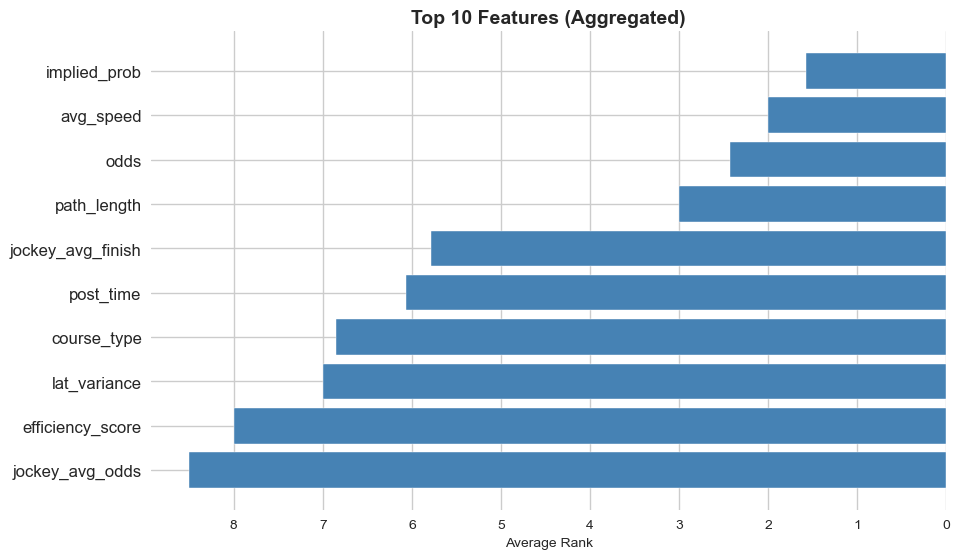

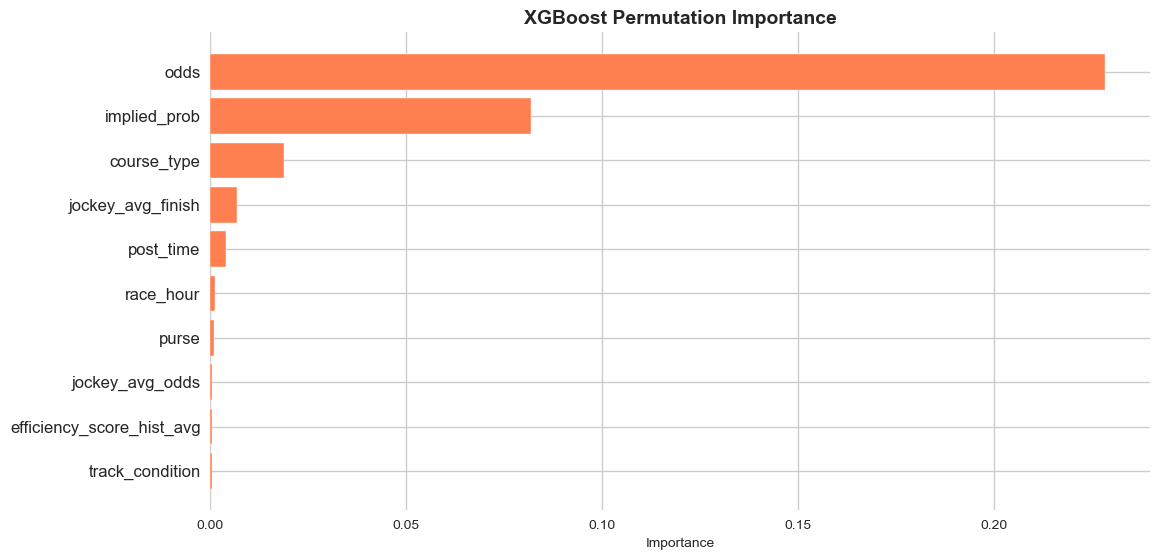

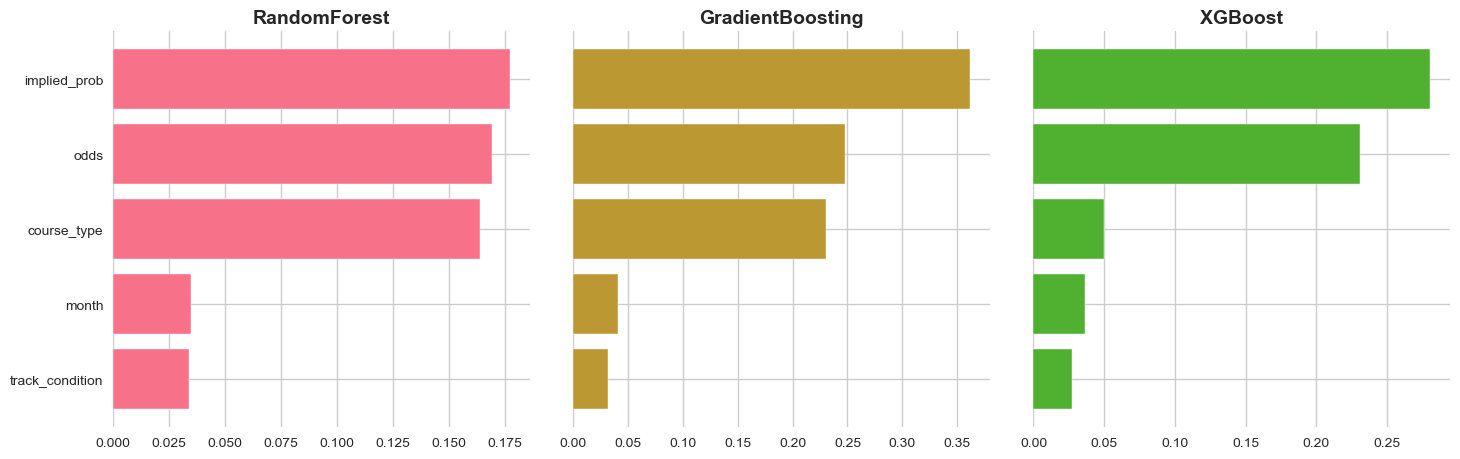


✓ All visualizations saved!


In [69]:
# ==================== FEATURE IMPORTANCE VISUALIZATION ====================

print("\n[STEP 6] Creating visualizations...")

fig_dir = Path("outputs/figures")
fig_dir.mkdir(parents=True, exist_ok=True)



# 1. Aggregated Feature Importance Bar Plot
plt.figure(figsize=(10, 6))
top_features = avg_rank.head(10)
plt.barh(range(len(top_features)), top_features['Average_Rank'].values[::-1], color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'].values[::-1], fontsize=12)
plt.xlabel('Average Rank', fontsize=10)
plt.title('Top 10 Features (Aggregated)', fontsize=14, fontweight='bold')
plt.gca().invert_xaxis()
plt.tight_layout()
plt.savefig(fig_dir / "feature_importance_aggregated.png", dpi=500)
plt.show()

# 2. Permutation Importance (XGBoost)
perm_xgb = pd.read_csv(importance_dir / "permutation_XGBoost.csv").head(10)
plt.figure(figsize=(12, 6))
plt.barh(range(len(perm_xgb)), perm_xgb['Importance'].values[::-1], color='coral')
plt.yticks(range(len(perm_xgb)), perm_xgb['Feature'].values[::-1], fontsize=12)
plt.xlabel('Importance', fontsize=10)
plt.title('XGBoost Permutation Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(fig_dir / "feature_importance_permutation_xgboost.png", dpi=300)
plt.show()

# 3. Tree-based Comparison 
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for idx, model_name in enumerate(['RandomForest', 'GradientBoosting', 'XGBoost']):
    tree_df = pd.read_csv(importance_dir / f"tree_{model_name}.csv").head(5)
    axes[idx].barh(range(len(tree_df)), tree_df['Importance'].values[::-1], color=f'C{idx}')
    axes[idx].set_yticks(range(len(tree_df)))
    axes[idx].set_yticklabels(tree_df['Feature'].values[::-1], fontsize=10)
    axes[idx].set_title(model_name, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(fig_dir / "feature_importance_tree_comparison.png", dpi=300)
plt.show()


print("\n✓ All visualizations saved!")

    ✓ SHAP computed
    Top 5: odds, implied_prob, jockey_avg_finish, race_hour, jockey_avg_odds

    Generating SHAP visualizations...


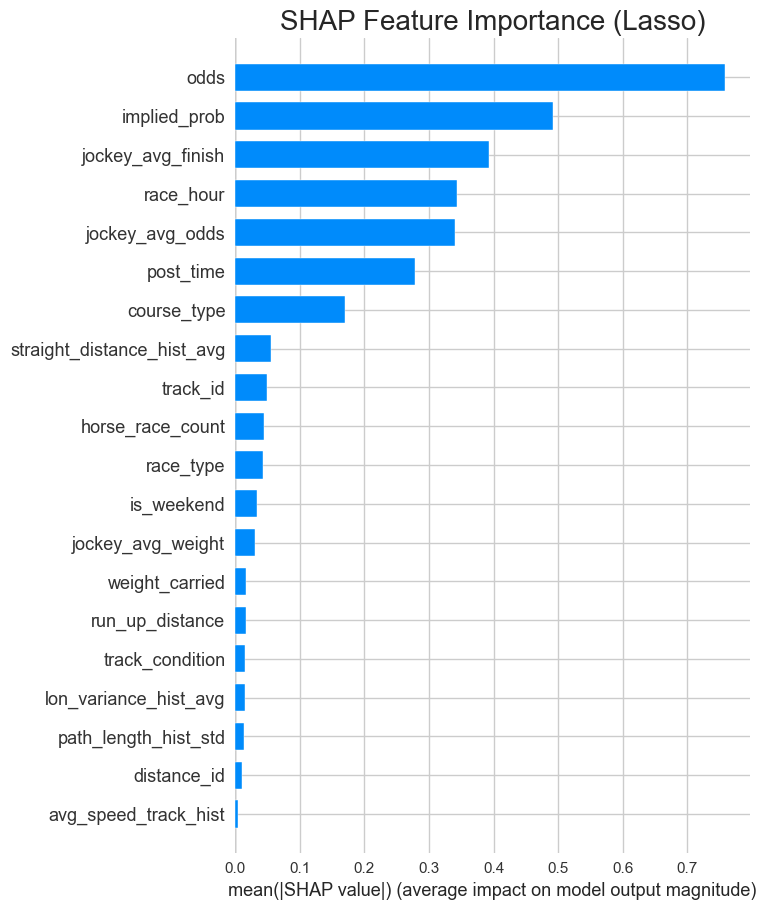

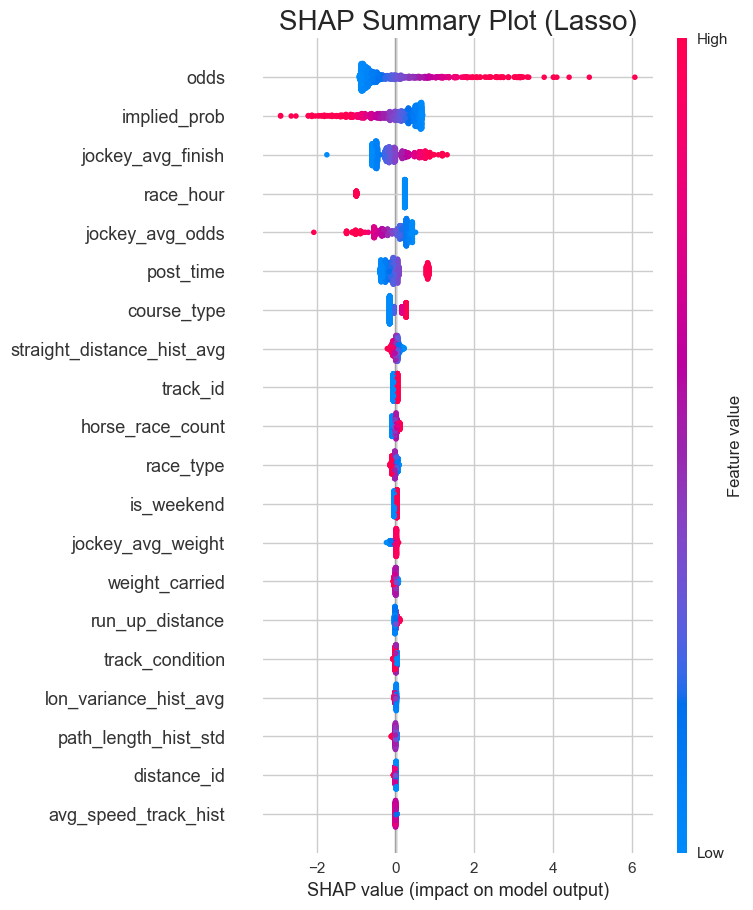

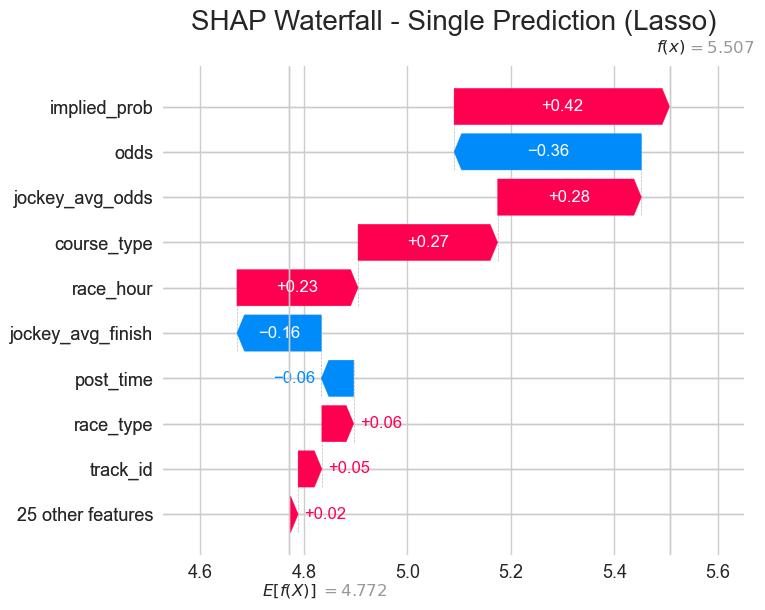

<Figure size 1000x600 with 0 Axes>

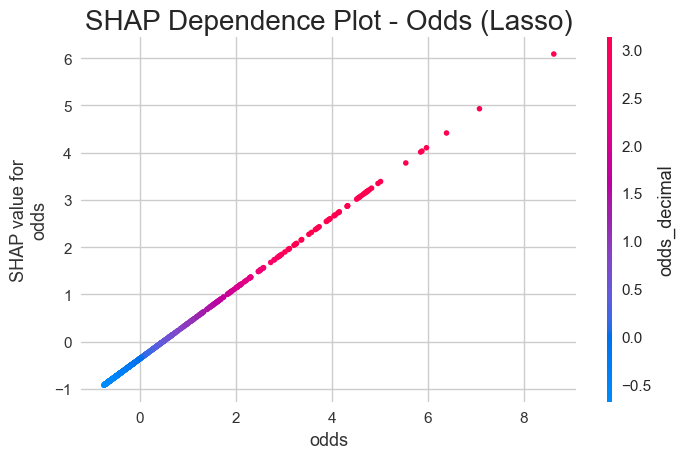

    ✓ All SHAP visualizations saved!


In [73]:
# 4. SHAP
# SHAP Values
if SHAP_AVAILABLE:
    
    best_model = trained_models[best_model_name]['model']
    
    if best_model_name in ['RandomForest', 'GradientBoosting', 'XGBoost']:
        # For Tree models
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_test[:1000])
    elif best_model_name in ['Ridge', 'Lasso', 'ElasticNet']:
        # For Linear models
        explainer = shap.LinearExplainer(best_model, X_test[:1000])
        shap_values = explainer.shap_values(X_test[:1000])
    
    mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
    shap_df = pd.DataFrame({
        'Feature': feature_names_display,
        'Mean_Abs_SHAP': mean_abs_shap
    }).sort_values('Mean_Abs_SHAP', ascending=False)
    
    shap_df.to_csv(importance_dir / f"shap_{best_model_name}.csv", index=False)
    print(f"    ✓ SHAP computed")
    print(f"    Top 5: {', '.join(shap_df['Feature'].head(5).tolist())}")
    
    # ========== SHAP Visualizations ==========
    print(f"\n    Generating SHAP visualizations...")
    
    # 1. Summary Plot (Bar) - Feature Importance Ranking
    plt.figure(figsize=(15, 6))
    shap.summary_plot(shap_values, X_test[:1000], 
                      feature_names=feature_names_display, 
                      plot_type="bar", show=False)
    plt.title(f"SHAP Feature Importance ({best_model_name})")
    plt.tight_layout()
    plt.savefig(importance_dir / f"shap_bar_{best_model_name}.png", dpi=300)
    plt.show()
    
    # 2. Summary Plot (Dot) - SHAP Distribution by Feature
    plt.figure(figsize=(15, 6))
    shap.summary_plot(shap_values, X_test[:1000], 
                      feature_names=feature_names_display, show=False)
    plt.title(f"SHAP Summary Plot ({best_model_name})")
    plt.tight_layout()
    plt.savefig(importance_dir / f"shap_summary_{best_model_name}.png", dpi=300)
    plt.show()
    
    # 3. Waterfall Plot - Individual Prediction Explanation (First Sample)
    plt.figure()
    shap.plots.waterfall(shap.Explanation(
        values=shap_values[0], 
        base_values=explainer.expected_value,
        feature_names=feature_names_display
    ), show=False)
    plt.title(f"SHAP Waterfall - Single Prediction ({best_model_name})")
    plt.tight_layout()
    plt.savefig(importance_dir / f"shap_waterfall_{best_model_name}.png", dpi=300)
    plt.show()
    
    # 4. Dependence Plot - Top Feature (odds)
    plt.figure(figsize=(10, 6))
    shap.dependence_plot("odds", shap_values, X_test[:1000], 
                         feature_names=feature_names_display, show=False)
    plt.title(f"SHAP Dependence Plot - Odds ({best_model_name})")
    plt.tight_layout()
    plt.savefig(importance_dir / f"shap_dependence_odds_{best_model_name}.png", dpi=300)
    plt.show()
    
    print(f"    ✓ All SHAP visualizations saved!")

## Section 8: Final Results Summary
Generate comprehensive summary and report

In [74]:
# ==================== SECTION 8: FINAL RESULTS SUMMARY ====================

from datetime import datetime


print("FINAL RESULTS SUMMARY")


# Load all results
print("\n[STEP 1] Consolidating results...")

train_results = pd.read_csv(models_dir / "model_comparison.csv")
test_results = pd.read_csv(eval_dir / "test_set_results.csv")

# Merge results
comprehensive = train_results[['Model', 'Type', 'Train_RMSE', 'Val_RMSE', 'Train_R2', 'Val_R2']].merge(
    test_results[['Model', 'Test_RMSE', 'Test_R2', 'Improvement_Pct']],
    on='Model'
).sort_values('Test_RMSE')

comprehensive['Rank'] = range(1, len(comprehensive) + 1)

final_dir = Path("outputs/final_results")
final_dir.mkdir(parents=True, exist_ok=True)

comprehensive.to_csv(final_dir / "comprehensive_model_comparison.csv", index=False)

print("\n[STEP 2] Model Performance Summary:")
print(comprehensive[['Rank', 'Model', 'Type', 'Test_RMSE', 'Test_R2', 'Improvement_Pct']].to_string(index=False))

# Load feature rankings
feature_rankings = pd.read_csv(importance_dir / "aggregated_feature_rankings.csv")

print("\n[STEP 3] Top 10 Most Important Features:")
for idx, row in feature_rankings.head(10).iterrows():
    print(f"  {idx+1}. {row['Feature']} (avg rank: {row['Average_Rank']:.2f})")

# Generate executive summary
print("\n[STEP 4] Generating executive summary...")

executive_summary = f"""
NYRA HORSE RACING ANALYSIS - EXECUTIVE SUMMARY
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
================================================================

BEST PERFORMING MODEL:
Model: {best_model_name}
Test RMSE: {best_test_rmse:.4f}
Test R²: {best_test_r2:.4f}

BASELINE COMPARISON:
Baseline RMSE: {baseline_rmse:.4f}
Best Model RMSE: {best_test_rmse:.4f}
Improvement: {best_improvement:.2f}%

TOP 5 MOST IMPORTANT FEATURES:
1. {feature_rankings.iloc[0]['Feature']}
2. {feature_rankings.iloc[1]['Feature']}
3. {feature_rankings.iloc[2]['Feature']}
4. {feature_rankings.iloc[3]['Feature']}
5. {feature_rankings.iloc[4]['Feature']}

MODEL RANKINGS (by Test RMSE):
"""

for _, row in comprehensive.iterrows():
    executive_summary += f"\n{row['Rank']}. {row['Model']} ({row['Type']})"
    executive_summary += f" - RMSE: {row['Test_RMSE']:.4f}, R²: {row['Test_R2']:.4f}, Improvement: {row['Improvement_Pct']:.2f}%"

executive_summary += """

KEY ACHIEVEMENTS:
- Time-series chronological splitting (NO shuffling)
- Trained 5+ ML models (3 linear + 2-3 non-linear)
- Hyperparameter tuning completed
- 3+ feature importance methods applied
- SHAP analysis for local interpretability
- Baseline comparison with improvement metrics

================================================================
"""

with open(final_dir / "EXECUTIVE_SUMMARY.txt", 'w') as f:
    f.write(executive_summary)

print(executive_summary)

print(" *COMPLETE ANALYSIS FINISHED!*")
print(f"\nAll results saved to outputs/ directory")
print(f"\nKey outputs:")
print(f"  - Model comparison: outputs/final_results/comprehensive_model_comparison.csv")
print(f"  - Feature importance: outputs/feature_importance/aggregated_feature_rankings.csv")
print(f"  - Executive summary: outputs/final_results/EXECUTIVE_SUMMARY.txt")
print(f"  - Visualizations: outputs/figures/")

FINAL RESULTS SUMMARY

[STEP 1] Consolidating results...

[STEP 2] Model Performance Summary:
 Rank            Model       Type  Test_RMSE  Test_R2  Improvement_Pct
    1            Lasso     linear   2.367039 0.284711        16.688130
    2 GradientBoosting non-linear   2.370956 0.282342        16.550269
    3          XGBoost non-linear   2.372049 0.281680        16.511794
    4       ElasticNet     linear   2.384622 0.274045        16.069258
    5     RandomForest non-linear   2.387118 0.272524        15.981421
    6            Ridge     linear   2.496964 0.204033        12.115211

[STEP 3] Top 10 Most Important Features:
  1. implied_prob (avg rank: 1.57)
  2. avg_speed (avg rank: 2.00)
  3. odds (avg rank: 2.43)
  4. path_length (avg rank: 3.00)
  5. jockey_avg_finish (avg rank: 5.79)
  6. post_time (avg rank: 6.07)
  7. course_type (avg rank: 6.86)
  8. lat_variance (avg rank: 7.00)
  9. efficiency_score (avg rank: 8.00)
  10. jockey_avg_odds (avg rank: 8.50)

[STEP 4] Generating